In [1]:
from pathlib import Path
import os, sys, json, hashlib, re, unicodedata, urllib.request, zipfile, shutil
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display, Markdown, FileLink
IN_COLAB = 'google.colab' in sys.modules or Path('/content').exists()
display(pd.DataFrame({'tool': ['Python', 'pandas', 'numpy', 'matplotlib'],
                      'version': [sys.version.split()[0], pd.__version__, np.__version__, matplotlib.__version__]}))

# Clear analysis names; Census IDs are retained only for source traceability.
TABLE_CONFIG = {'internet_access': 'B28002', 'computing_devices': 'B28003', 'household_income': 'B19013', 'poverty_status': 'C17002', 'age': 'B01002'}
ACS_COLUMN_NAMES = {'B28002_E001': 'households', 'B28002_M001': 'households_moe', 'B28002_E002': 'internet_subscription_households', 'B28002_M002': 'internet_subscription_households_moe', 'B28002_E003': 'dialup_only_subscription_households', 'B28002_M003': 'dialup_only_subscription_households_moe', 'B28002_E004': 'any_broadband_subscription_households', 'B28002_M004': 'any_broadband_subscription_households_moe', 'B28002_E005': 'cellular_subscription_households', 'B28002_M005': 'cellular_subscription_households_moe', 'B28002_E006': 'cellular_only_subscription_households', 'B28002_M006': 'cellular_only_subscription_households_moe', 'B28002_E007': 'cable_fiber_dsl_subscription_households', 'B28002_M007': 'cable_fiber_dsl_subscription_households_moe', 'B28002_E008': 'cable_fiber_dsl_only_subscription_households', 'B28002_M008': 'cable_fiber_dsl_only_subscription_households_moe', 'B28002_E009': 'satellite_subscription_households', 'B28002_M009': 'satellite_subscription_households_moe', 'B28002_E010': 'satellite_only_subscription_households', 'B28002_M010': 'satellite_only_subscription_households_moe', 'B28002_E011': 'other_only_subscription_households', 'B28002_M011': 'other_only_subscription_households_moe', 'B28002_E012': 'internet_access_without_subscription_households', 'B28002_M012': 'internet_access_without_subscription_households_moe', 'B28002_E013': 'no_internet_access_households', 'B28002_M013': 'no_internet_access_households_moe', 'B28003_E001': 'device_table_households', 'B28003_M001': 'device_table_households_moe', 'B28003_E002': 'computing_device_households', 'B28003_M002': 'computing_device_households_moe', 'B28003_E003': 'computing_device_with_dialup_only_households', 'B28003_M003': 'computing_device_with_dialup_only_households_moe', 'B28003_E004': 'computing_device_with_broadband_households', 'B28003_M004': 'computing_device_with_broadband_households_moe', 'B28003_E005': 'computing_device_without_subscription_households', 'B28003_M005': 'computing_device_without_subscription_households_moe', 'B28003_E006': 'no_computing_device_households', 'B28003_M006': 'no_computing_device_households_moe', 'B19013_E001': 'median_household_income_usd', 'B19013_M001': 'median_household_income_usd_moe', 'C17002_E001': 'poverty_universe_population', 'C17002_M001': 'poverty_universe_population_moe', 'C17002_E002': 'income_poverty_ratio_under_0_50_population', 'C17002_M002': 'income_poverty_ratio_under_0_50_population_moe', 'C17002_E003': 'income_poverty_ratio_0_50_to_0_99_population', 'C17002_M003': 'income_poverty_ratio_0_50_to_0_99_population_moe', 'C17002_E004': 'income_poverty_ratio_1_00_to_1_24_population', 'C17002_M004': 'income_poverty_ratio_1_00_to_1_24_population_moe', 'C17002_E005': 'income_poverty_ratio_1_25_to_1_49_population', 'C17002_M005': 'income_poverty_ratio_1_25_to_1_49_population_moe', 'C17002_E006': 'income_poverty_ratio_1_50_to_1_84_population', 'C17002_M006': 'income_poverty_ratio_1_50_to_1_84_population_moe', 'C17002_E007': 'income_poverty_ratio_1_85_to_1_99_population', 'C17002_M007': 'income_poverty_ratio_1_85_to_1_99_population_moe', 'C17002_E008': 'income_poverty_ratio_2_00_or_more_population', 'C17002_M008': 'income_poverty_ratio_2_00_or_more_population_moe', 'B01002_E001': 'median_age_years', 'B01002_M001': 'median_age_years_moe', 'B01002_E002': 'male_median_age_years', 'B01002_M002': 'male_median_age_years_moe', 'B01002_E003': 'female_median_age_years', 'B01002_M003': 'female_median_age_years_moe'}
assert len(set(ACS_COLUMN_NAMES.values())) == len(ACS_COLUMN_NAMES)
display(Markdown('### Variable names used throughout this notebook'))
display(pd.DataFrame([{'dataset': name, 'Census source table': table} for name, table in TABLE_CONFIG.items()]))
display(pd.DataFrame([{'analysis variable': ACS_COLUMN_NAMES[code], 'original Census column': code} for code in ['B28002_E001','B28002_E013','B28002_E006','B28003_E006','B19013_E001','B01002_E001','C17002_E001']]))
print('Counts end in households or population; percentages end in pct; moe means margin of error.')

,tool,version
0,Python,3.12.14
1,pandas,2.2.3
2,numpy,2.3.5
3,matplotlib,3.11.2


### Variable names used throughout this notebook

,dataset,Census source table
0,internet_access,B28002
1,computing_devices,B28003
2,household_income,B19013
3,poverty_status,C17002
4,age,B01002


,analysis variable,original Census column
0,households,B28002_E001
1,no_internet_access_households,B28002_E013
2,cellular_only_subscription_households,B28002_E006
3,no_computing_device_households,B28003_E006
4,median_household_income_usd,B19013_E001
5,median_age_years,B01002_E001
6,poverty_universe_population,C17002_E001


Counts end in households or population; percentages end in pct; moe means margin of error.


In [2]:
DATA_MODE = 'github'  # Choose 'github', 'drive', or 'upload'.
SNAPSHOT_URL = 'https://raw.githubusercontent.com/We1Chen7/nj-digital-equity/main/NJ_Digital_Equity_Data.zip'
EXPECTED_ZIP_SHA256 = 'caaafd135c4b0a77c488970cf876df858905ebab543e34d60fedc8876701e115'
ROOT = Path(os.environ.get('NJ_COLAB_ROOT', '/content/NJ_Digital_Equity' if IN_COLAB else '/tmp/NJ_Digital_Equity_Colab_Check'))
RAW, CLEAN, RESULTS = ROOT / 'data/raw', ROOT / 'data/processed', ROOT / 'results'
FIGURES = RESULTS / 'figures'
for folder in [ROOT, RAW, CLEAN, RESULTS, FIGURES]:
    folder.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titleweight': 'bold'})
display(pd.DataFrame({'purpose': ['Input mode', 'Raw files', 'Processed CSVs', 'Results'],
                      'location': [DATA_MODE, str(RAW), str(CLEAN), str(RESULTS)]}))

,purpose,location
0,Input mode,github
1,Raw files,/tmp/NJ_Digital_Equity_Colab_Check/data/raw
2,Processed CSVs,/tmp/NJ_Digital_Equity_Colab_Check/data/processed
3,Results,/tmp/NJ_Digital_Equity_Colab_Check/results


In [3]:
zip_path = ROOT / 'NJ_Digital_Equity_Data.zip'
local_check_bundle = os.environ.get('NJ_COLAB_BUNDLE')
if local_check_bundle:  # Used only for the local reproducibility check.
    shutil.copyfile(local_check_bundle, zip_path)
elif DATA_MODE == 'github':
    with urllib.request.urlopen(SNAPSHOT_URL, timeout=90) as response:
        zip_path.write_bytes(response.read())
elif DATA_MODE == 'drive':
    from google.colab import drive
    drive.mount('/content/drive')
    shutil.copyfile('/content/drive/MyDrive/NJ_Digital_Equity/NJ_Digital_Equity_Data.zip', zip_path)
elif DATA_MODE == 'upload':
    from google.colab import files
    uploaded = files.upload()
    assert 'NJ_Digital_Equity_Data.zip' in uploaded, 'Select the data ZIP.'
    zip_path.write_bytes(uploaded['NJ_Digital_Equity_Data.zip'])
else:
    raise ValueError('Choose github, drive, or upload.')
actual_sha = hashlib.sha256(zip_path.read_bytes()).hexdigest()
assert actual_sha == EXPECTED_ZIP_SHA256, 'Snapshot differs; stop and inspect the source.'
print('ZIP verified:', zip_path.name, '| bytes:', zip_path.stat().st_size)
print('SHA-256:', actual_sha)

ZIP verified: NJ_Digital_Equity_Data.zip | bytes: 907799
SHA-256: caaafd135c4b0a77c488970cf876df858905ebab543e34d60fedc8876701e115


In [4]:
with zipfile.ZipFile(zip_path) as archive:
    for member in archive.infolist():
        assert (ROOT / member.filename).resolve().is_relative_to(ROOT.resolve()), 'Unsafe ZIP path'
    archive.extractall(ROOT)
inventory = pd.DataFrame([{'file': str(p.relative_to(ROOT)), 'bytes': p.stat().st_size}
                          for p in sorted(RAW.glob('*')) if p.is_file()])
display(inventory)
print('Raw source files:', len(inventory))

,file,bytes
0,data/raw/B01002_metadata.json,202206
1,data/raw/B19013_metadata.json,200530
2,data/raw/B28002_metadata.json,217542
3,data/raw/B28003_metadata.json,206932
4,data/raw/C17002_metadata.json,209720
5,data/raw/download_manifest.json,5269
6,data/raw/nj_B01002.dat,106880
7,data/raw/nj_B19013.dat,74028
8,data/raw/nj_B28002.dat,245618
9,data/raw/nj_B28003.dat,142517


Raw source files: 15


In [5]:
manifest = json.loads((RAW / 'download_manifest.json').read_text())
for filename, entry in manifest.items():
    actual = hashlib.sha256((RAW / filename).read_bytes()).hexdigest()
    assert actual == entry['saved_sha256'], 'File changed: ' + filename
source_log = pd.DataFrame([
    {'file': name, 'downloaded_utc': item['downloaded_utc'],
     'rows': item.get('retained_rows', item.get('rows')),
     'source_url': item['url']}
    for name, item in manifest.items()
])

source_log.to_csv(RESULTS / "source_log.csv", index=False)
display(source_log)
print("PASS: every source file matches its checksum.")

,file,downloaded_utc,rows,source_url
0,nj_assets_metadata.json,2026-10-06T19:16:15.694702+00:00,NaN,https://data.nj.gov/api/views/yjm4-bujw.json
1,nj_assets_page_0.json,2026-10-06T19:16:16.229881+00:00,NaN,https://data.nj.gov/resource/yjm4-bujw.json?$l...
2,nj_assets_all.json,2026-10-07T16:53:18.209142+00:00,614.0,https://data.nj.gov/resource/yjm4-bujw.json
3,B28002_metadata.json,2026-10-06T19:16:16.426474+00:00,NaN,https://api.census.gov/data/2024/acs/acs5/grou...
4,nj_B28002.dat,2026-10-06T19:16:18.019458+00:00,2203.0,https://www2.census.gov/programs-surveys/acs/s...
5,B28003_metadata.json,2026-10-06T19:16:18.201611+00:00,NaN,https://api.census.gov/data/2024/acs/acs5/grou...
6,nj_B28003.dat,2026-10-06T19:16:27.761279+00:00,2203.0,https://www2.census.gov/programs-surveys/acs/s...
7,B19013_metadata.json,2026-10-06T19:16:27.947906+00:00,NaN,https://api.census.gov/data/2024/acs/acs5/grou...
8,nj_B19013.dat,2026-10-06T19:16:33.838150+00:00,2203.0,https://www2.census.gov/programs-surveys/acs/s...
9,C17002_metadata.json,2026-10-06T19:16:34.043654+00:00,NaN,https://api.census.gov/data/2024/acs/acs5/grou...


PASS: every source file matches its checksum.


In [6]:
TABLES = list(TABLE_CONFIG.values())
geo = pd.read_csv(RAW / 'nj_geographies.txt', sep='|', dtype=str, keep_default_na=False)
data = geo[['GEO_ID', 'NAME', 'STATE', 'COUNTY', 'TRACT', 'SUMLEVEL']].copy()
assert data['GEO_ID'].is_unique
display(data.head())
display(data['SUMLEVEL'].value_counts().rename_axis('summary_level').reset_index(name='rows'))

,GEO_ID,NAME,STATE,COUNTY,TRACT,SUMLEVEL
0,0400000US34,New Jersey,34,,,040
1,0500000US34001,"Atlantic County, New Jersey",34,001,,050
2,0500000US34003,"Bergen County, New Jersey",34,003,,050
3,0500000US34005,"Burlington County, New Jersey",34,005,,050
4,0500000US34007,"Camden County, New Jersey",34,007,,050


,summary_level,rows
0,140,2181
1,050,21
2,040,1


In [7]:
raw_example = pd.read_csv(RAW / 'nj_B28002.dat', sep='|', dtype=str).rename(columns=ACS_COLUMN_NAMES)
display(raw_example[['GEO_ID', 'households', 'no_internet_access_households', 'no_internet_access_households_moe']].head())
print('Rows:', len(raw_example), '| Columns:', len(raw_example.columns))

,GEO_ID,households,no_internet_access_households,no_internet_access_households_moe
0,0400000US34,3507701,189079,4292
1,0500000US34001,109557,7155,792
2,0500000US34003,355127,13522,974
3,0500000US34005,177222,6585,615
4,0500000US34007,202540,11531,988


Rows: 2203 | Columns: 27


In [8]:
special_values = []
for table in TABLES:
    part = pd.read_csv(RAW / f'nj_{table}.dat', sep='|', dtype=str)
    assert part['GEO_ID'].is_unique
    assert set(part['GEO_ID']) == set(data['GEO_ID'])
    for col in part.columns[1:]:
        numeric = pd.to_numeric(part[col], errors='coerce')
        invalid = numeric.isna() | numeric.lt(0)
        special_values.append({'column': ACS_COLUMN_NAMES[col], 'original_census_column': col, 'special_or_missing_rows': int(invalid.sum())})
        part[col] = numeric.mask(numeric.lt(0))
    assert set(part.columns[1:]).issubset(ACS_COLUMN_NAMES)
    part = part.rename(columns=ACS_COLUMN_NAMES)
    data = data.merge(part, on='GEO_ID', how='left', validate='one_to_one')

display(data[['GEO_ID', 'NAME', 'households', 'median_household_income_usd', 'poverty_universe_population']].head())
print('Joined rows:', len(data), '| Columns:', len(data.columns))
assert not any(re.fullmatch(r'[BC][0-9]{5}_[EM][0-9]{3}', col) for col in data.columns)
print('PASS: all analysis columns have descriptive names.')

,GEO_ID,NAME,households,median_household_income_usd,poverty_universe_population
0,0400000US34,New Jersey,3507701,103556.0,9180234
1,0500000US34001,"Atlantic County, New Jersey",109557,78050.0,270285
2,0500000US34003,"Bergen County, New Jersey",355127,124884.0,951352
3,0500000US34005,"Burlington County, New Jersey",177222,108111.0,457553
4,0500000US34007,"Camden County, New Jersey",202540,88755.0,521654


Joined rows: 2203 | Columns: 68
PASS: all analysis columns have descriptive names.


In [9]:
data['geoid'] = data['GEO_ID'].str.split('US').str[-1]
tract = data.loc[data['SUMLEVEL'].eq('140')].copy()
county = data.loc[data['SUMLEVEL'].eq('050')].copy()
state = data.loc[data['SUMLEVEL'].eq('040')].copy()
display(pd.DataFrame({'unit': ['tract', 'county', 'state'],
                      'rows': [len(tract), len(county), len(state)]}))
display(tract[['geoid', 'NAME', 'households', 'no_internet_access_households']].head())
pd.DataFrame(special_values).to_csv(RESULTS / 'census_special_values.csv', index=False)

,unit,rows
0,tract,2181
1,county,21
2,state,1


,geoid,NAME,households,no_internet_access_households
22,34001000100,"Census Tract 1, Atlantic County, New Jersey",813,78
23,34001000200,"Census Tract 2, Atlantic County, New Jersey",1457,355
24,34001000300,"Census Tract 3, Atlantic County, New Jersey",1474,206
25,34001000400,"Census Tract 4, Atlantic County, New Jersey",1584,144
26,34001000500,"Census Tract 5, Atlantic County, New Jersey",999,98


In [10]:
special_review = pd.DataFrame(special_values)
display(special_review.query('special_or_missing_rows > 0').sort_values('special_or_missing_rows', ascending=False).head(15))
print('Household denominators equal to zero:', int(tract['households'].eq(0).sum()))

,column,original_census_column,special_or_missing_rows
39,median_household_income_usd_moe,B19013_M001,72
38,median_household_income_usd,B19013_E001,31
60,female_median_age_years,B01002_E003,18
61,female_median_age_years_moe,B01002_M003,18
58,male_median_age_years,B01002_E002,14
59,male_median_age_years_moe,B01002_M002,14
56,median_age_years,B01002_E001,11
57,median_age_years_moe,B01002_M001,11


Household denominators equal to zero: 15


The internet categories must add to the household total, and numerator counts must fall within their denominators. All checks must pass.

In [11]:
checks = []
def check(name, passed, detail):
    checks.append({'check': name, 'passed': bool(passed), 'detail': str(detail)})
check('21 county rows', len(county) == 21, len(county))
check('One state row', len(state) == 1, len(state))
check('Unique tract GEOIDs', tract['geoid'].is_unique, len(tract))
check('All rows belong to NJ', data['STATE'].eq('34').all(), 'State FIPS 34')
check('Household totals agree across internet and device tables',
      data['households'].eq(data['device_table_households']).all(), 'B28002 vs B28003')
check('Internet categories add to total',
      data['internet_subscription_households'].add(data['internet_access_without_subscription_households']).add(data['no_internet_access_households']).eq(data['households']).all(),
      'Subscription + access without subscription + no access')
check('Device categories add to total',
      data['computing_device_households'].add(data['no_computing_device_households']).eq(data['device_table_households']).all(),
      'Has a computer + no computer')
for field in ['no_internet_access_households', 'cellular_only_subscription_households', 'cable_fiber_dsl_subscription_households', 'no_computing_device_households']:
    valid = data[field].notna() & data['households'].notna()
    check(field + ' is within total households',
          data.loc[valid, field].between(0, data.loc[valid, 'households']).all(),
          int(valid.sum()))
quality = pd.DataFrame(checks)
display(quality)
quality.to_csv(RESULTS / 'quality_checks.csv', index=False)
assert quality['passed'].all(), 'Investigate failed checks before using results.'
print('Tracts with zero households:', int(tract['households'].eq(0).sum()))
print('Tract-to-state household sum difference:', tract['households'].sum() - state['households'].iloc[0])

,check,passed,detail
0,21 county rows,True,21
1,One state row,True,1
2,Unique tract GEOIDs,True,2181
3,All rows belong to NJ,True,State FIPS 34
4,Household totals agree across internet and dev...,True,B28002 vs B28003
5,Internet categories add to total,True,Subscription + access without subscription + n...
6,Device categories add to total,True,Has a computer + no computer
7,no_internet_access_households is within total ...,True,2203
8,cellular_only_subscription_households is withi...,True,2203
9,cable_fiber_dsl_subscription_households is wit...,True,2203


Tracts with zero households: 15
Tract-to-state household sum difference: 0


Calculate indicators

In [12]:
# Calculate indicators

RATE_SPECS = {
    'no_internet_access_pct': ('no_internet_access_households', 'households'),
    'cellular_only_subscription_pct': ('cellular_only_subscription_households', 'households'),
    'cable_fiber_dsl_subscription_pct': ('cable_fiber_dsl_subscription_households', 'households'),
    'no_computing_device_pct': ('no_computing_device_households', 'device_table_households'),
}
def add_indicators(frame):
    frame = frame.copy()
    frame['households'] = frame['households']
    for name, (num, den) in RATE_SPECS.items():
        frame[name] = 100 * frame[num] / frame[den].where(frame[den] > 0)
    frame['no_internet_subscription_pct'] = 100 * (frame['internet_access_without_subscription_households'] + frame['no_internet_access_households']) / frame['households'].where(frame['households'] > 0)
    frame['poverty_pct'] = 100 * (frame['income_poverty_ratio_under_0_50_population'] + frame['income_poverty_ratio_0_50_to_0_99_population']) / frame['poverty_universe_population'].where(frame['poverty_universe_population'] > 0)
    frame['median_household_income_usd'] = frame['median_household_income_usd']
    frame['income_upper_bound_flag'] = frame['median_household_income_usd'].ge(250001)
    frame['median_age_years'] = frame['median_age_years']
    return frame
tract, county, state = [add_indicators(frame) for frame in [tract, county, state]]

display(tract[['NAME', 'households', 'no_internet_access_pct', 'poverty_pct', 'median_household_income_usd']].head().round(2))
print('Tracts with a valid household denominator:', int(tract['households'].gt(0).sum()))

,NAME,households,no_internet_access_pct,poverty_pct,median_household_income_usd
22,"Census Tract 1, Atlantic County, New Jersey",813,9.59,20.25,56222.0
23,"Census Tract 2, Atlantic County, New Jersey",1457,24.37,20.74,42346.0
24,"Census Tract 3, Atlantic County, New Jersey",1474,13.98,28.27,52763.0
25,"Census Tract 4, Atlantic County, New Jersey",1584,9.09,30.43,50104.0
26,"Census Tract 5, Atlantic County, New Jersey",999,9.81,25.39,53378.0


Tracts with a valid household denominator: 2166


## 13. Read the variable dictionary

Source metadata supplies the original definitions. Count margins of error are retained; derived percentages do not yet have calculated confidence intervals.

**Checkpoint:** inspect the output before continuing.

In [13]:
dictionary_rows = []
for dataset_name, table in TABLE_CONFIG.items():
    metadata = json.loads((RAW / f'{table}_metadata.json').read_text())['variables']
    for original, name in ACS_COLUMN_NAMES.items():
        match = re.fullmatch(table + r'_([EM])([0-9]{3})', original)
        if match and name in data.columns:
            api_name = f'{table}_{match.group(2)}{match.group(1)}'
            dictionary_rows.append({'variable': name, 'original_census_column': original,
                                    'definition': metadata[api_name]['label'],
                                    'source': f'https://api.census.gov/data/2024/acs/acs5/groups/{table}.html'})
for name, (num, den) in RATE_SPECS.items():
    dictionary_rows.append({'variable': name, 'definition': f'100 * {num} / {den}; percentage points; denominator > 0', 'source': 'Derived from ACS'})
dictionary_rows += [
    {'variable': 'no_internet_subscription_pct', 'definition': '100 * (internet_access_without_subscription_households + no_internet_access_households) / household total', 'source': 'Derived from ACS'},
    {'variable': 'poverty_pct', 'definition': '100 * (income_poverty_ratio_under_0_50_population + income_poverty_ratio_0_50_to_0_99_population) / poverty_universe_population; income/poverty ratio below 1', 'source': 'Derived from ACS'},
    {'variable': 'median_household_income_usd', 'definition': 'median_household_income_usd; dollars adjusted to 2024; upper-bound values flagged', 'source': 'ACS B19013'},
    {'variable': 'income_upper_bound_flag', 'definition': 'Median income >= 250001; inspect reporting bound before modeling', 'source': 'ACS B19013'},
    {'variable': 'median_age_years', 'definition': 'median_age_years; median age in years', 'source': 'ACS B01002'},
]
dictionary = pd.DataFrame(dictionary_rows)
dictionary.to_csv(CLEAN / 'variable_dictionary.csv', index=False)
display(dictionary.loc[dictionary['variable'].isin(RATE_SPECS)].reset_index(drop=True))

,variable,original_census_column,definition,source
0,no_internet_access_pct,NaN,100 * no_internet_access_households / househol...,Derived from ACS
1,cellular_only_subscription_pct,NaN,100 * cellular_only_subscription_households / ...,Derived from ACS
2,cable_fiber_dsl_subscription_pct,NaN,100 * cable_fiber_dsl_subscription_households ...,Derived from ACS
3,no_computing_device_pct,NaN,100 * no_computing_device_households / device_...,Derived from ACS


## 14. Check one percentage by hand

Compare the household numerator, denominator and calculated percentage for five tracts. This makes the calculation visible.

**Checkpoint:** inspect the output before continuing.

In [14]:
example = tract.loc[tract['households'].gt(0), ['NAME', 'no_internet_access_households', 'households', 'no_internet_access_pct']].head().copy()
example['manual_check_pct'] = 100 * example['no_internet_access_households'] / example['households']
assert np.allclose(example['manual_check_pct'], example['no_internet_access_pct'])
display(example.round(3))
print('PASS: the manual calculations match.')

,NAME,no_internet_access_households,households,no_internet_access_pct,manual_check_pct
22,"Census Tract 1, Atlantic County, New Jersey",78,813,9.594,9.594
23,"Census Tract 2, Atlantic County, New Jersey",355,1457,24.365,24.365
24,"Census Tract 3, Atlantic County, New Jersey",206,1474,13.976,13.976
25,"Census Tract 4, Atlantic County, New Jersey",144,1584,9.091,9.091
26,"Census Tract 5, Atlantic County, New Jersey",98,999,9.810,9.810


PASS: the manual calculations match.


## 15. Describe the tract data and statewide estimates

The tract summary weights each tract equally. Statewide percentages use the official state row and answer a different question.

**Checkpoint:** inspect the output before continuing.

In [15]:
METRICS = list(RATE_SPECS) + ['no_internet_subscription_pct', 'poverty_pct', 'median_household_income_usd', 'median_age_years']
desc = tract[METRICS].describe(percentiles=[.25, .5, .75]).T
desc['missing'] = tract[METRICS].isna().sum()
display(desc.round(2))
desc.to_csv(RESULTS / 'tract_descriptive_statistics.csv')
display(state[['NAME', 'households'] + list(RATE_SPECS)].round(2))

,count,mean,std,min,25%,50%,75%,max,missing
no_internet_access_pct,2166.0,5.61,6.45,0.0,1.81,3.88,7.31,100.00,15
cellular_only_subscription_pct,2166.0,10.58,5.91,0.0,6.42,9.38,13.42,42.19,15
cable_fiber_dsl_subscription_pct,2166.0,80.09,10.92,0.0,75.00,82.28,87.87,100.00,15
no_computing_device_pct,2166.0,4.22,5.04,0.0,1.32,3.01,5.62,100.00,15
no_internet_subscription_pct,2166.0,7.34,7.09,0.0,2.95,5.56,9.59,100.00,15
poverty_pct,2168.0,10.33,10.04,0.0,3.66,7.02,13.53,100.00,13
median_household_income_usd,2150.0,112053.34,50085.73,15943.0,75631.25,103495.00,139934.00,250001.00,31
median_age_years,2170.0,41.29,8.06,12.2,36.80,40.80,45.00,76.00,11


,NAME,households,no_internet_access_pct,cellular_only_subscription_pct,cable_fiber_dsl_subscription_pct,no_computing_device_pct
0,New Jersey,3507701,5.39,10.34,80.64,4.06


## 16. Inspect unusually high rates

Very small household denominators can produce extreme percentages. Review the count margin of error; do not interpret every extreme as a precise estimate.

**Checkpoint:** inspect the output before continuing.

In [16]:
extreme_rates = tract.nlargest(5, 'no_internet_access_pct')[
    ['NAME', 'households', 'no_internet_access_households', 'no_internet_access_households_moe', 'no_internet_access_pct']]
display(extreme_rates.round(2))
extreme_rates.to_csv(RESULTS / 'extreme_rate_review.csv', index=False)

,NAME,households,no_internet_access_households,no_internet_access_households_moe,no_internet_access_pct
2179,"Census Tract 9800, Union County, New Jersey",9,9,14,100.00
1685,"Census Tract 7154.03, Ocean County, New Jersey",739,574,148,77.67
1386,"Census Tract 9800, Middlesex County, New Jersey",17,13,21,76.47
1682,"Census Tract 7153.03, Ocean County, New Jersey",611,373,145,61.05
1683,"Census Tract 7153.04, Ocean County, New Jersey",1049,635,202,60.53


## 17. Chart the distribution across tracts

The histogram shows how many tracts fall into each percentage range. Each tract contributes once.

**Checkpoint:** inspect the output before continuing.

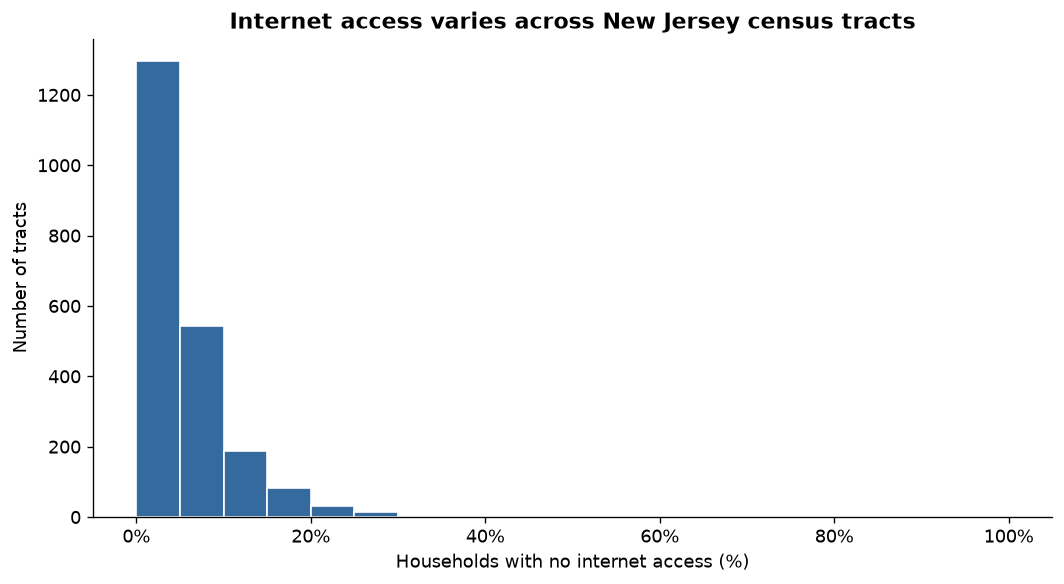

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(tract['no_internet_access_pct'].dropna(), bins=np.arange(0, 101, 5), color='#346A9E', edgecolor='white')
ax.set(title='Internet access varies across New Jersey census tracts', xlabel='Households with no internet access (%)', ylabel='Number of tracts')
ax.xaxis.set_major_formatter(PercentFormatter(100))
fig.tight_layout(); fig.savefig(FIGURES / '01_tract_distribution.png', dpi=170); plt.show()

## 18. Compare the 21 counties

These bars show official county estimates. Ranking alone does not establish statistically significant differences.

**Checkpoint:** inspect the output before continuing.

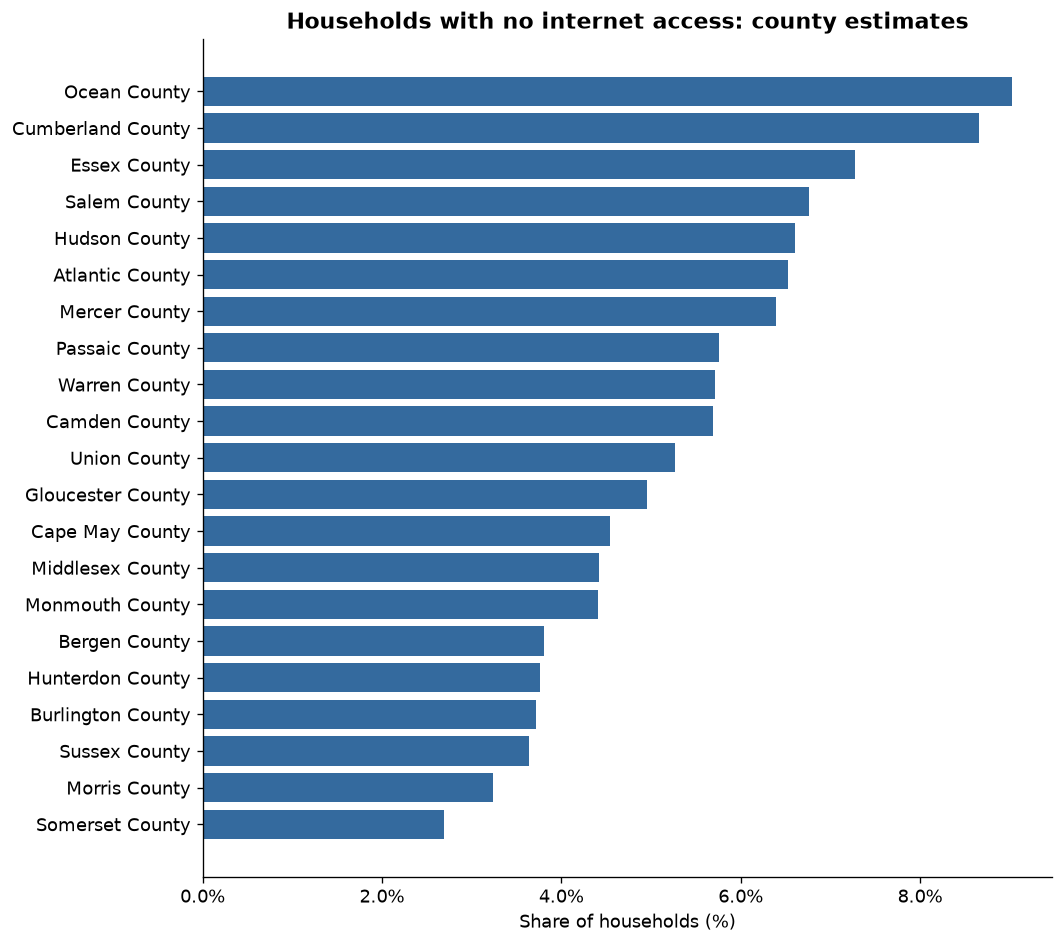

In [18]:
ranked = county.sort_values('no_internet_access_pct')
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(ranked['NAME'].str.replace(', New Jersey', '', regex=False), ranked['no_internet_access_pct'], color='#346A9E')
ax.set(title='Households with no internet access: county estimates', xlabel='Share of households (%)')
ax.xaxis.set_major_formatter(PercentFormatter(100))
fig.tight_layout(); fig.savefig(FIGURES / '02_county_comparison.png', dpi=170); plt.show()

## 19. Explore poverty and internet access

Each point is a tract. The correlation describes an ecological association; it cannot establish an individual relationship or causation.

**Checkpoint:** inspect the output before continuing.

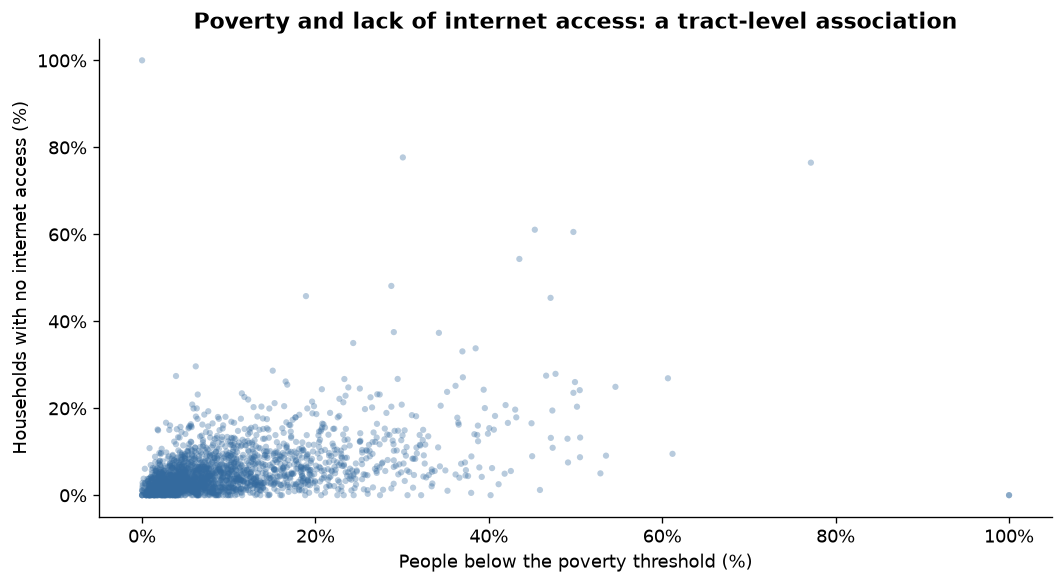

Unweighted tract Pearson correlation: 0.462; complete pairs: 2,166
This is a community-level association, not an individual or causal effect.


In [19]:
scatter = tract[['poverty_pct', 'no_internet_access_pct']].dropna()
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(scatter['poverty_pct'], scatter['no_internet_access_pct'], s=14, alpha=.35, color='#346A9E', edgecolors='none')
ax.set(title='Poverty and lack of internet access: a tract-level association', xlabel='People below the poverty threshold (%)', ylabel='Households with no internet access (%)')
ax.xaxis.set_major_formatter(PercentFormatter(100)); ax.yaxis.set_major_formatter(PercentFormatter(100))
fig.tight_layout(); fig.savefig(FIGURES / '03_poverty_and_access.png', dpi=170); plt.show()
correlation = scatter.corr().iloc[0, 1]
print(f'Unweighted tract Pearson correlation: {correlation:.3f}; complete pairs: {len(scatter):,}')
print('This is a community-level association, not an individual or causal effect.')

## 20. Open the organization directory

One row is a directory record. Review the organization name, type and reported service area before counting services.

**Checkpoint:** inspect the output before continuing.

In [20]:
source_assets = json.loads((RAW / 'nj_assets_all.json').read_text())
assets = pd.json_normalize(source_assets)

display(assets[['organization_name1', 'organization_type', 'geographic_service_area', 'city']].head(10))
print('Raw directory records:', len(assets))

,organization_name1,organization_type,geographic_service_area,city
0,XCHANGE TELECOM LLC,INTERNET SERVICE PROVIDER,OCEAN COUNTY,Brooklyn
1,THE HISPANIC FAMILY CENTER OF SOUTHERN NJ,LOCAL NONPROFIT,CAMDEN COUNTY,Camden and Woodbury
2,TDI CONNECT,LOCAL NONPROFIT,MERCER COUNTY,Hamilton
3,BOROUGH OF ROSELLE,LOCAL GOVERNMENT,UNION COUNTY,Roselle
4,HOPES CAP INC,LOCAL NONPROFIT,HUDSON COUNTY,Hoboken
5,NJCEDV,LOCAL NONPROFIT,STATEWIDE,Hamilton
6,GROTTA FUND FOR OLDER ADULTS,FOUNDATION/PHILANTHROPIC,MORRIS COUNTY,Whippany
7,"MFA, INC",LOCAL NONPROFIT,SERVICE EXTENT IS LIMITED TO MUNICIPALITY LEVEL.,Blairstown
8,"ATTOBAHN, INC",PRIVATE SECTOR,ESSEX COUNTY,Montclair
9,NJ TRANSIT,STATE GOVERNMENT,STATEWIDE,Newark


Raw directory records: 614


## 21. Flag duplicate names and service descriptions

Flags identify repeated name/address groups and selected wording. Text flags do not verify program capacity. Records explicitly stating no direct program stay visible.

**Checkpoint:** inspect the output before continuing.

In [21]:
def normalize(value):
    if pd.isna(value): return ''
    return re.sub(r'\s+', ' ', unicodedata.normalize('NFKC', str(value))).strip().upper()
for col in ['organization_name1', 'street_address', 'city', 'zip_code', 'cover_population_s', 'area_focus', 'geographic_service_area']:
    if col not in assets: assets[col] = ''
    assets[col + '_normalized'] = assets[col].map(normalize)
assets['record_number'] = np.arange(1, len(assets) + 1)
dup_keys = ['organization_name1_normalized', 'street_address_normalized', 'city_normalized', 'zip_code_normalized']
assets['duplicate_name_address_flag'] = assets.duplicated(dup_keys, keep=False)
assets['explicit_no_direct_program_flag'] = assets['cover_population_s_normalized'].str.contains('NO SPECIFIC/DIRECT DIGITAL INCLUSION PROGRAM', regex=False)
assets['digital_literacy_text_flag'] = assets['area_focus_normalized'].str.contains('DIGITAL LITERACY', regex=False)
assets['statewide_service_text_flag'] = assets['geographic_service_area_normalized'].str.replace('-', '', regex=False).str.contains('STATEWIDE', regex=False)

display(assets[['organization_name1', 'duplicate_name_address_flag', 'explicit_no_direct_program_flag', 'digital_literacy_text_flag', 'statewide_service_text_flag']].head(10))
print('Records explicitly reporting no direct program:', int(assets['explicit_no_direct_program_flag'].sum()))

,organization_name1,duplicate_name_address_flag,explicit_no_direct_program_flag,digital_literacy_text_flag,statewide_service_text_flag
0,XCHANGE TELECOM LLC,False,False,False,False
1,THE HISPANIC FAMILY CENTER OF SOUTHERN NJ,False,False,False,False
2,TDI CONNECT,False,False,False,False
3,BOROUGH OF ROSELLE,False,False,False,False
4,HOPES CAP INC,False,False,False,False
5,NJCEDV,False,False,False,True
6,GROTTA FUND FOR OLDER ADULTS,False,False,False,False
7,"MFA, INC",False,False,False,False
8,"ATTOBAHN, INC",False,False,False,False
9,NJ TRANSIT,False,False,False,True


Records explicitly reporting no direct program: 99


## 22. Check recorded locations

The approximate NJ bounding box is only a screening tool. An out-of-state office may serve NJ residents. An office location does not establish its service area.

**Checkpoint:** inspect the output before continuing.

In [22]:
coordinates = [entry.get('geocode', {}).get('coordinates', []) for entry in source_assets]
assets['longitude'] = [point[0] if len(point) == 2 else np.nan for point in coordinates]
assets['latitude'] = [point[1] if len(point) == 2 else np.nan for point in coordinates]
assets['coordinate_missing_flag'] = assets[['longitude', 'latitude']].isna().any(axis=1)
assets['outside_nj_bounding_box_flag'] = (~assets['coordinate_missing_flag']) & ~(assets['longitude'].between(-75.60, -73.85) & assets['latitude'].between(38.90, 41.36))

display(assets.loc[assets['coordinate_missing_flag'] | assets['outside_nj_bounding_box_flag'],
                   ['organization_name1', 'city', 'geographic_service_area', 'longitude', 'latitude', 'coordinate_missing_flag', 'outside_nj_bounding_box_flag']].head(12))
print('Missing coordinates:', int(assets['coordinate_missing_flag'].sum()))

,organization_name1,city,geographic_service_area,longitude,latitude,coordinate_missing_flag,outside_nj_bounding_box_flag
124,BASS RIVER COMMUNITY LIBRARY,NaN,NaN,0.000000,0.000000,False,True
357,BLACK CHURCHES FOR DIGITAL EQUITY,NaN,NaN,-77.042322,38.906875,False,True
380,SALEM/CUMBERLAND COUNTY,Trenton,SALEM COUNTY,NaN,NaN,True,False
391,VETERANS LEADERSHIP COUNCIL,NaN,NaN,-87.636631,41.882608,False,True
408,BRIGHT SPRINGS RES CARE,Statewide,STATEWIDE,-85.583447,38.257485,False,True
472,HOUSING PRESERVATION INCORPORATED,NaN,STATEWIDE,-89.868295,35.110128,False,True
535,PROJECT FREEDOM,Statewide,STATEWIDE,0.000000,0.000000,False,True
581,TURNING POINT,Statewide,STATEWIDE,0.000000,0.000000,False,True
583,UI REHAB NEW JERSEY SERVICES,Statewide,STATEWIDE,0.000000,0.000000,False,True
599,Bordentown Library,Bordentown,BURLINGTON COUNTY;,NaN,NaN,True,False


Missing coordinates: 16


## 23. Summarize directory quality

Flag categories can overlap, so do not add their counts together. The directory cannot demonstrate that areas with no recorded organizations have no services.

**Checkpoint:** inspect the output before continuing.

In [23]:
asset_quality = pd.DataFrame([
    {'measure': 'Raw directory records', 'count': len(assets)},
    {'measure': 'Unique normalized organization names (not necessarily service sites)', 'count': assets['organization_name1_normalized'].nunique()},
    {'measure': 'Records in repeated name/address groups (all members flagged)', 'count': int(assets['duplicate_name_address_flag'].sum())},
    {'measure': 'Missing coordinates', 'count': int(assets['coordinate_missing_flag'].sum())},
    {'measure': 'Coordinates outside approximate NJ bounding box', 'count': int(assets['outside_nj_bounding_box_flag'].sum())},
    {'measure': 'Text explicitly says no direct digital inclusion program', 'count': int(assets['explicit_no_direct_program_flag'].sum())},
    {'measure': 'Area-focus text mentions digital literacy', 'count': int(assets['digital_literacy_text_flag'].sum())},
    {'measure': 'Service-area text mentions statewide coverage', 'count': int(assets['statewide_service_text_flag'].sum())},
])
display(asset_quality)
asset_quality.to_csv(RESULTS / 'asset_quality_summary.csv', index=False)
display(assets[['organization_name1', 'organization_type', 'geographic_service_area', 'city', 'digital_literacy_text_flag', 'explicit_no_direct_program_flag']].head(10))
missing_assets = assets[[c for c in ['organization_name1', 'street_address', 'city', 'zip_code', 'geographic_service_area', 'area_focus'] if c in assets]].isna().sum().rename('missing_records').to_frame()
display(missing_assets)
missing_assets.to_csv(RESULTS / 'asset_field_missingness.csv')

,measure,count
0,Raw directory records,614
1,Unique normalized organization names (not nece...,606
2,Records in repeated name/address groups (all m...,2
3,Missing coordinates,16
4,Coordinates outside approximate NJ bounding box,8
5,Text explicitly says no direct digital inclusi...,99
6,Area-focus text mentions digital literacy,306
7,Service-area text mentions statewide coverage,112


,organization_name1,organization_type,geographic_service_area,city,digital_literacy_text_flag,explicit_no_direct_program_flag
0,XCHANGE TELECOM LLC,INTERNET SERVICE PROVIDER,OCEAN COUNTY,Brooklyn,False,False
1,THE HISPANIC FAMILY CENTER OF SOUTHERN NJ,LOCAL NONPROFIT,CAMDEN COUNTY,Camden and Woodbury,False,False
2,TDI CONNECT,LOCAL NONPROFIT,MERCER COUNTY,Hamilton,False,False
3,BOROUGH OF ROSELLE,LOCAL GOVERNMENT,UNION COUNTY,Roselle,False,False
4,HOPES CAP INC,LOCAL NONPROFIT,HUDSON COUNTY,Hoboken,False,False
5,NJCEDV,LOCAL NONPROFIT,STATEWIDE,Hamilton,False,False
6,GROTTA FUND FOR OLDER ADULTS,FOUNDATION/PHILANTHROPIC,MORRIS COUNTY,Whippany,False,False
7,"MFA, INC",LOCAL NONPROFIT,SERVICE EXTENT IS LIMITED TO MUNICIPALITY LEVEL.,Blairstown,False,False
8,"ATTOBAHN, INC",PRIVATE SECTOR,ESSEX COUNTY,Montclair,False,False
9,NJ TRANSIT,STATE GOVERNMENT,STATEWIDE,Newark,False,False


,missing_records
organization_name1,0
street_address,47
city,41
zip_code,63
geographic_service_area,18
area_focus,11


## 24. Chart the organization types

The chart counts directory records by reported organization type. It does not measure service effectiveness.

**Checkpoint:** inspect the output before continuing.

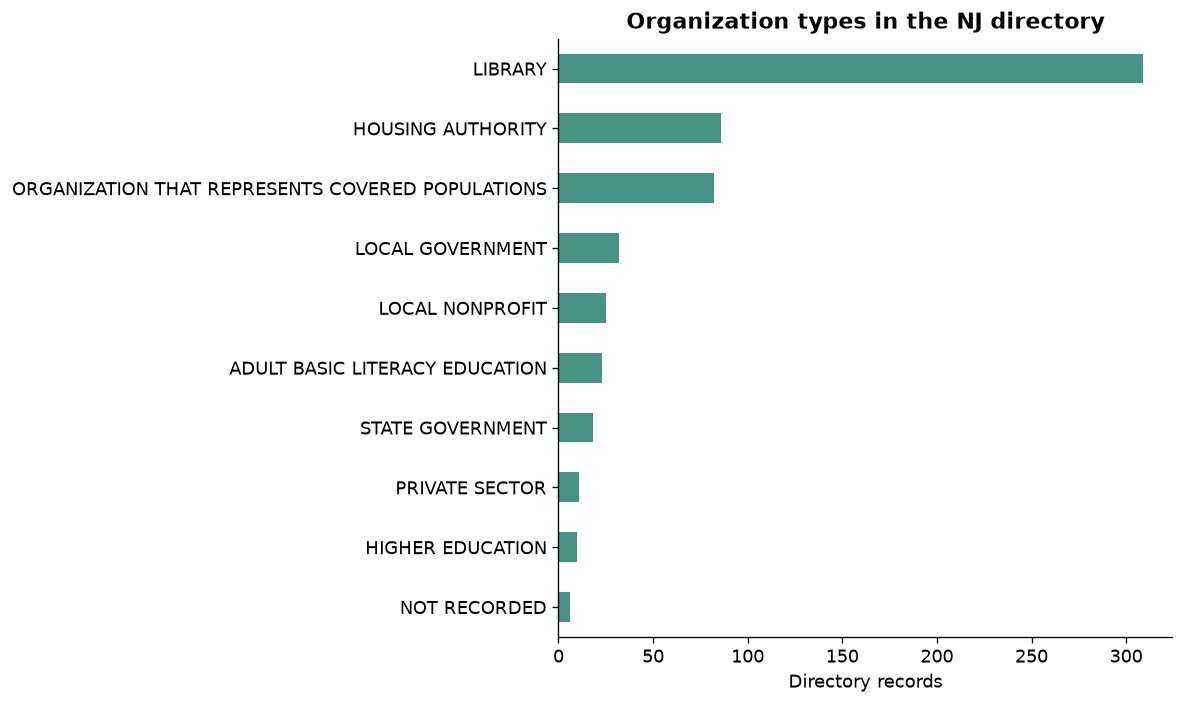

Directory rows last updated (UTC): 2025-05-23 17:16:43+00:00
Flags overlap. Do not add the flag counts together.


In [24]:
counts = assets['organization_type'].fillna('NOT RECORDED').map(normalize).value_counts()
counts.rename_axis('organization_type').reset_index(name='records').to_csv(RESULTS / 'asset_organization_types.csv', index=False)
fig, ax = plt.subplots(figsize=(10, 6))
counts.head(10).sort_values().plot.barh(ax=ax, color='#479487')
ax.set(title='Organization types in the NJ directory', xlabel='Directory records', ylabel='')
fig.tight_layout(); fig.savefig(FIGURES / '04_resource_directory.png', dpi=170); plt.show()
asset_metadata = json.loads((RAW / 'nj_assets_metadata.json').read_text())
print('Directory rows last updated (UTC):', pd.to_datetime(asset_metadata['rowsUpdatedAt'], unit='s', utc=True))
print('Flags overlap. Do not add the flag counts together.')

## 25. Save the analysis and summarize the findings

Save clean tables, quality reports and a short findings note. Findings remain descriptive. No causal or infrastructure-availability model is produced.

**Checkpoint:** inspect the output before continuing.

In [25]:
tract.to_csv(CLEAN / 'nj_tract_digital_equity_2020_2024.csv', index=False)
county.to_csv(CLEAN / 'nj_county_digital_equity_2020_2024.csv', index=False)
state.to_csv(CLEAN / 'nj_state_digital_equity_2020_2024.csv', index=False)
# Raw records stay intact. The public analysis CSV omits contact-person details.
public_assets = assets.drop(columns=[c for c in assets if c.startswith(('contact_', 'geocode'))], errors='ignore')
public_assets.to_csv(CLEAN / 'nj_digital_inclusion_assets_flagged.csv', index=False)
acs_rate_cols = [c for c in tract if c.endswith('_pct')]
assert tract[acs_rate_cols].stack().between(0, 100).all()
source_status = pd.DataFrame([
    {'source': 'ACS 2024 five-year tables and geographies', 'status': 'Downloaded and verified', 'analysis_use': '2020-2024 community access conditions'},
    {'source': 'NJ OBC asset directory', 'status': 'Downloaded; quality limitations flagged', 'analysis_use': 'Directory description; spatial and service verification still required'},
    {'source': 'FCC National Broadband Map', 'status': 'Not downloaded; account/API access not configured', 'analysis_use': 'No infrastructure-availability variables in this dataset'},
])
source_status.to_csv(RESULTS / 'source_verification.csv', index=False)
display(source_status)
s = state.iloc[0]
findings = {
    'acs_period': '2020-2024', 'tracts': len(tract), 'counties': len(county),
    'tracts_with_positive_households': int(tract['households'].gt(0).sum()),
    'state_households': int(s['households']),
    'state_no_internet_access_pct': float(s['no_internet_access_pct']),
    'state_no_computing_device_pct': float(s['no_computing_device_pct']),
    'state_cellular_only_subscription_pct': float(s['cellular_only_subscription_pct']),
    'tract_poverty_access_correlation': float(correlation),
    'raw_asset_records': len(assets),
    'asset_quality': asset_quality.to_dict('records'),
}
(RESULTS / 'findings.json').write_text(json.dumps(findings, indent=2))
note = f"""# Initial descriptive findings

ACS period: 2020-2024. Tracts: {len(tract):,}; counties: {len(county)}.
Tracts with positive household denominators: {findings['tracts_with_positive_households']:,}.
State households (estimated): {findings['state_households']:,}.

Using the official state row, {s['no_internet_access_pct']:.2f}% of households
had no internet access, {s['no_computing_device_pct']:.2f}% had no computing device,
and {s['cellular_only_subscription_pct']:.2f}% had a cellular-only internet subscription.
The unweighted tract correlation between poverty and no internet access was
{correlation:.3f}. This is a descriptive ecological association, not causation.

The NJ resource directory contains {len(assets):,} raw records. Consult
asset_quality_summary.csv before counting service sites. Directory observations
are not capacity measurements, and a zero directory count would not establish
absence of services. Raw count margins of error are retained. Derived percentages
do not yet have calculated confidence intervals.

FCC availability was not downloaded. No resource-distance or causal model is
reported. The directory snapshot and ACS reference period differ.
"""
(RESULTS / 'INITIAL_FINDINGS.md').write_text(note)
display(Markdown(note))
print('Saved processed CSVs, quality tables, figures, source log and findings.')

,source,status,analysis_use
0,ACS 2024 five-year tables and geographies,Downloaded and verified,2020-2024 community access conditions
1,NJ OBC asset directory,Downloaded; quality limitations flagged,Directory description; spatial and service ver...
2,FCC National Broadband Map,Not downloaded; account/API access not configured,No infrastructure-availability variables in th...


# Initial descriptive findings

ACS period: 2020-2024. Tracts: 2,181; counties: 21.
Tracts with positive household denominators: 2,166.
State households (estimated): 3,507,701.

Using the official state row, 5.39% of households
had no internet access, 4.06% had no computing device,
and 10.34% had a cellular-only internet subscription.
The unweighted tract correlation between poverty and no internet access was
0.462. This is a descriptive ecological association, not causation.

The NJ resource directory contains 614 raw records. Consult
asset_quality_summary.csv before counting service sites. Directory observations
are not capacity measurements, and a zero directory count would not establish
absence of services. Raw count margins of error are retained. Derived percentages
do not yet have calculated confidence intervals.

FCC availability was not downloaded. No resource-distance or causal model is
reported. The directory snapshot and ACS reference period differ.


Saved processed CSVs, quality tables, figures, source log and findings.


## 26. Check the saved CSVs

Reopen the files to confirm their row counts and inspect the main tract CSV. Keep GEOIDs as strings when loading them elsewhere.

**Checkpoint:** inspect the output before continuing.

In [26]:
saved = []
for p in sorted(CLEAN.glob('*.csv')):
    check_frame = pd.read_csv(p, dtype={'geoid': str, 'GEO_ID': str})
    saved.append({'file': p.name, 'rows': len(check_frame), 'columns': len(check_frame.columns)})
display(pd.DataFrame(saved))
reopened = pd.read_csv(CLEAN / 'nj_tract_digital_equity_2020_2024.csv', dtype={'geoid': str})
assert len(reopened) == len(tract) and reopened['geoid'].is_unique
display(reopened[['geoid', 'NAME', 'households', 'no_internet_access_pct']].head().round(2))
print('PASS: saved tract keys and row count match.')

,file,rows,columns
0,nj_county_digital_equity_2020_2024.csv,21,76
1,nj_digital_inclusion_assets_flagged.csv,614,29
2,nj_state_digital_equity_2020_2024.csv,1,76
3,nj_tract_digital_equity_2020_2024.csv,2181,76
4,variable_dictionary.csv,71,4


,geoid,NAME,households,no_internet_access_pct
0,34001000100,"Census Tract 1, Atlantic County, New Jersey",813,9.59
1,34001000200,"Census Tract 2, Atlantic County, New Jersey",1457,24.37
2,34001000300,"Census Tract 3, Atlantic County, New Jersey",1474,13.98
3,34001000400,"Census Tract 4, Atlantic County, New Jersey",1584,9.09
4,34001000500,"Census Tract 5, Atlantic County, New Jersey",999,9.81


PASS: saved tract keys and row count match.


## 27. Package the results

This output ZIP contains processed CSVs, reports and PNG charts. It excludes the raw snapshot to avoid duplicating it. The next cell can save it to Drive.

**Checkpoint:** inspect the output before continuing.

In [27]:
OUTPUT_ZIP = ROOT / 'NJ_Digital_Equity_Results.zip'
with zipfile.ZipFile(OUTPUT_ZIP, 'w', zipfile.ZIP_DEFLATED) as archive:
    for folder in [CLEAN, RESULTS]:
        for p in sorted(folder.rglob('*')):
            if p.is_file():
                archive.write(p, p.relative_to(ROOT))
with zipfile.ZipFile(OUTPUT_ZIP) as archive:
    assert archive.testzip() is None
    display(pd.DataFrame([{'file': x.filename, 'bytes': x.file_size} for x in archive.infolist()]))
print('Results ZIP verified:', OUTPUT_ZIP.name)
display(FileLink(str(OUTPUT_ZIP)))

,file,bytes
0,data/processed/nj_county_digital_equity_2020_2...,12808
1,data/processed/nj_digital_inclusion_assets_fla...,265504
2,data/processed/nj_state_digital_equity_2020_20...,3087
3,data/processed/nj_tract_digital_equity.gpkg,13504512
4,data/processed/nj_tract_digital_equity_2020_20...,976442
5,data/processed/variable_dictionary.csv,12041
6,results/INITIAL_FINDINGS.md,975
7,results/asset_field_missingness.csv,117
8,results/asset_organization_types.csv,393
9,results/asset_quality_summary.csv,406


Results ZIP verified: NJ_Digital_Equity_Results.zip


/tmp/NJ_Digital_Equity_Colab_Check/NJ_Digital_Equity_Results.zip

## 28. Optionally save results to Google Drive

Set `SAVE_TO_DRIVE = True` when you want to copy the results ZIP to the same Drive folder. The default skips account access. Colab mounting requires your Google authorization. To download to your computer instead, uncomment the last two lines.

**Checkpoint:** inspect the output before continuing.

In [28]:
SAVE_TO_DRIVE = False
if SAVE_TO_DRIVE:
    assert IN_COLAB, 'This option is for a Colab runtime.'
    from google.colab import drive
    drive.mount('/content/drive')
    destination = Path('/content/drive/MyDrive/NJ_Digital_Equity')
    destination.mkdir(parents=True, exist_ok=True)
    shutil.copy2(OUTPUT_ZIP, destination / OUTPUT_ZIP.name)
    print('Saved to Google Drive:', destination / OUTPUT_ZIP.name)
else:
    print('Drive copy skipped. Results ZIP is ready in the runtime Files panel.')
    print('Set SAVE_TO_DRIVE = True and rerun this cell to save it to Drive.')
# from google.colab import files
# files.download(str(OUTPUT_ZIP))

Drive copy skipped. Results ZIP is ready in the runtime Files panel.
Set SAVE_TO_DRIVE = True and rerun this cell to save it to Drive.


## Write three sentences in English

1. “The unit of analysis is …”
2. “The county comparison shows …”
3. “This result does not establish …”

**Next research decision:** verify program types, service areas and actual service
locations before creating resource-access measures. Align time periods, calculate
uncertainty, and define the theoretical outcome before choosing a regression.

## Official sources

- [ACS 2024 summary files](https://www.census.gov/programs-surveys/acs/data/summary-file.2024.html)
- [B28002 internet definitions](https://api.census.gov/data/2024/acs/acs5/groups/B28002.html)
- [B28003 device definitions](https://api.census.gov/data/2024/acs/acs5/groups/B28003.html)
- [NJ OBC directory](https://data.nj.gov/resource/yjm4-bujw.json)
- [NJ mapping hub](https://www.nj.gov/connect/resources/mapping/)

The exact source files and collection timestamps are listed in Step 5. To collect
a new snapshot, use `download_data.py` in a new dated project folder; preserve the
existing snapshot used in your paper.

In [29]:
# 29. Where did the data come from, and what do they measure?
# Source descriptions are rendered here, inside this code cell's output.
display(Markdown('## 29. Data sources and measurement definitions'))
sources = pd.DataFrame([
    ['ACS B28002', 'Internet access and subscription types', 'Households', '2020–2024', 'https://api.census.gov/data/2024/acs/acs5/groups/B28002.html'],
    ['ACS B28003', 'Computing devices and internet subscriptions', 'Households; computer includes smartphones', '2020–2024', 'https://api.census.gov/data/2024/acs/acs5/groups/B28003.html'],
    ['ACS B19013', 'Median household income', 'Households; 2024 inflation-adjusted USD', '2020–2024', 'https://api.census.gov/data/2024/acs/acs5/groups/B19013.html'],
    ['ACS C17002', 'Income-to-poverty ratio', 'Population for whom poverty status is determined', '2020–2024', 'https://api.census.gov/data/2024/acs/acs5/groups/C17002.html'],
    ['ACS B01002', 'Median age', 'Total population; years', '2020–2024', 'https://api.census.gov/data/2024/acs/acs5/groups/B01002.html'],
    ['NJ OBC asset directory', 'Organizations and reported digital-inclusion resources', 'Directory records, not verified program capacity', str(pd.to_datetime(asset_metadata['rowsUpdatedAt'], unit='s', utc=True).date()), 'https://data.nj.gov/resource/yjm4-bujw.json'],
    ['2024 TIGER/Line', 'New Jersey census tract boundary polygons', 'Census tract geography; join on GEOID', '2024 boundary vintage', 'https://www2.census.gov/geo/tiger/TIGER2024/TRACT/tl_2024_34_tract.zip'],
], columns=['source', 'content', 'universe / unit', 'reference period', 'official link'])
display(sources.style.set_properties(**{'white-space': 'normal', 'text-align': 'left'}))
definitions = pd.DataFrame([
    ['no_internet_access_pct', 'no_internet_access_households / households × 100', 'Households without any internet access'],
    ['no_internet_subscription_pct', '(internet_access_without_subscription_households + no_internet_access_households) / households × 100', 'No subscription; some may still have access'],
    ['cellular_only_subscription_pct', 'cellular_only_subscription_households / households × 100', 'Subscription type; does not mean smartphone-only ownership'],
    ['poverty_pct', '(income_poverty_ratio_under_0_50_population + income_poverty_ratio_0_50_to_0_99_population) / poverty_universe_population × 100', 'People below the poverty threshold'],
    ['median_household_income_usd', 'median_household_income_usd', 'Median, not mean; values at 250001 are upper-bound flags'],
], columns=['variable', 'calculation / source', 'interpretation'])
display(definitions)
display(Markdown('The **ACS 2024 five-year release estimates conditions over 2020–2024**. It is not a one-year panel. The source data were downloaded from official Census summary files; exact URLs, collection timestamps and checksums appear in Step 5. TIGER/Line supplies geometry, not socioeconomic observations.'))

## 29. Data sources and measurement definitions

,source,content,universe / unit,reference period,official link
0,ACS B28002,Internet access and subscription types,Households,2020–2024,https://api.census.gov/data/2024/acs/acs5/groups/B28002.html
1,ACS B28003,Computing devices and internet subscriptions,Households; computer includes smartphones,2020–2024,https://api.census.gov/data/2024/acs/acs5/groups/B28003.html
2,ACS B19013,Median household income,Households; 2024 inflation-adjusted USD,2020–2024,https://api.census.gov/data/2024/acs/acs5/groups/B19013.html
3,ACS C17002,Income-to-poverty ratio,Population for whom poverty status is determined,2020–2024,https://api.census.gov/data/2024/acs/acs5/groups/C17002.html
4,ACS B01002,Median age,Total population; years,2020–2024,https://api.census.gov/data/2024/acs/acs5/groups/B01002.html
5,NJ OBC asset directory,Organizations and reported digital-inclusion resources,"Directory records, not verified program capacity",2025-05-23,https://data.nj.gov/resource/yjm4-bujw.json
6,2024 TIGER/Line,New Jersey census tract boundary polygons,Census tract geography; join on GEOID,2024 boundary vintage,https://www2.census.gov/geo/tiger/TIGER2024/TRACT/tl_2024_34_tract.zip


,variable,calculation / source,interpretation
0,no_internet_access_pct,no_internet_access_households / households × 100,Households without any internet access
1,no_internet_subscription_pct,(internet_access_without_subscription_househol...,No subscription; some may still have access
2,cellular_only_subscription_pct,cellular_only_subscription_households / househ...,Subscription type; does not mean smartphone-on...
3,poverty_pct,(income_poverty_ratio_under_0_50_population + ...,People below the poverty threshold
4,median_household_income_usd,median_household_income_usd,"Median, not mean; values at 250001 are upper-b..."


The **ACS 2024 five-year release estimates conditions over 2020–2024**. It is not a one-year panel. The source data were downloaded from official Census summary files; exact URLs, collection timestamps and checksums appear in Step 5. TIGER/Line supplies geometry, not socioeconomic observations.

In [30]:
# 30. Describe the data in the notebook instead of creating another codebook.
display(Markdown('## 30. Descriptive information for the research dataset'))
descriptive_columns = ['no_internet_access_pct', 'no_internet_subscription_pct',
                       'cellular_only_subscription_pct', 'no_computing_device_pct',
                       'poverty_pct', 'median_household_income_usd', 'median_age_years']
summary = tract[descriptive_columns].agg(['count', 'mean', 'std', 'min', 'median', 'max']).T
summary['missing'] = tract[descriptive_columns].isna().sum()
summary['p25'] = tract[descriptive_columns].quantile(.25)
summary['p75'] = tract[descriptive_columns].quantile(.75)
display(summary[['count', 'missing', 'mean', 'std', 'min', 'p25', 'median', 'p75', 'max']].round(2))
state_description = state[['NAME', 'households'] + descriptive_columns].copy()
display(state_description.round(2))
display(pd.DataFrame({'check': ['Tracts', 'Counties', 'Zero-household tracts',
                              'Tracts with fewer than 100 households', 'Upper-bound median incomes', 'NJ directory records'],
                      'number': [len(tract), len(county), int(tract['households'].eq(0).sum()),
                                 int(tract['households'].lt(100).sum()), int(tract['income_upper_bound_flag'].sum()), len(assets)]}))
display(Markdown(f"We observe **{len(tract):,} tracts**, including **{int(tract['households'].gt(0).sum()):,}** with positive household denominators. The statewide household estimate is **{int(state.iloc[0]['households']):,}**. Using the official state row, **{state.iloc[0]['no_internet_access_pct']:.2f}%** had no internet access. Across tracts, the median no-access share is **{tract['no_internet_access_pct'].median():.2f}%**. These are different summaries: the tract table gives each tract equal weight; statewide percentages use state household counts. The mean of tract median incomes is not the statewide median income."))
display(Markdown('The poverty/access Pearson correlation is **' + f'{correlation:.3f}' + '**. It describes a tract-level association. It does not establish individual behavior or causation. Raw count margins of error are retained; percentage confidence intervals have not yet been calculated.'))
summary.to_csv(RESULTS / 'expanded_descriptive_statistics.csv')

## 30. Descriptive information for the research dataset

,count,missing,mean,std,min,p25,median,p75,max
no_internet_access_pct,2166.0,15,5.61,6.45,0.0,1.81,3.88,7.31,100.00
no_internet_subscription_pct,2166.0,15,7.34,7.09,0.0,2.95,5.56,9.59,100.00
cellular_only_subscription_pct,2166.0,15,10.58,5.91,0.0,6.42,9.38,13.42,42.19
no_computing_device_pct,2166.0,15,4.22,5.04,0.0,1.32,3.01,5.62,100.00
poverty_pct,2168.0,13,10.33,10.04,0.0,3.66,7.02,13.53,100.00
median_household_income_usd,2150.0,31,112053.34,50085.73,15943.0,75631.25,103495.00,139934.00,250001.00
median_age_years,2170.0,11,41.29,8.06,12.2,36.80,40.80,45.00,76.00


,NAME,households,no_internet_access_pct,no_internet_subscription_pct,cellular_only_subscription_pct,no_computing_device_pct,poverty_pct,median_household_income_usd,median_age_years
0,New Jersey,3507701,5.39,7.09,10.34,4.06,9.72,103556.0,40.1


,check,number
0,Tracts,2181
1,Counties,21
2,Zero-household tracts,15
3,Tracts with fewer than 100 households,24
4,Upper-bound median incomes,41
5,NJ directory records,614


We observe **2,181 tracts**, including **2,166** with positive household denominators. The statewide household estimate is **3,507,701**. Using the official state row, **5.39%** had no internet access. Across tracts, the median no-access share is **3.88%**. These are different summaries: the tract table gives each tract equal weight; statewide percentages use state household counts. The mean of tract median incomes is not the statewide median income.

The poverty/access Pearson correlation is **0.462**. It describes a tract-level association. It does not establish individual behavior or causation. Raw count margins of error are retained; percentage confidence intervals have not yet been calculated.

In [31]:
# 31. Load the GIS tools. Install from PyPI only if GeoPandas is absent.
display(Markdown('## 31. GIS tools and coordinate systems'))
import importlib.util, subprocess
if importlib.util.find_spec('geopandas') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'geopandas>=1.0,<2'])
import geopandas as gpd
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
display(pd.DataFrame({'tool': ['GeoPandas', 'Map projection'],
                      'value': [gpd.__version__, 'EPSG:32111 — NAD83 / New Jersey (meters)']}))
print('A shapefile needs its .shp, .shx, .dbf and .prj companion files; retain the complete ZIP.')

## 31. GIS tools and coordinate systems

,tool,value
0,GeoPandas,1.2.0
1,Map projection,EPSG:32111 — NAD83 / New Jersey (meters)


A shapefile needs its .shp, .shx, .dbf and .prj companion files; retain the complete ZIP.


In [32]:
# 32. Download the official shapefile and verify the exact archive.
display(Markdown('## 32. Official New Jersey tract shapefile'))
from datetime import datetime, timezone
GIS = ROOT / 'data/gis'
GIS.mkdir(parents=True, exist_ok=True)
GIS_URL = 'https://www2.census.gov/geo/tiger/TIGER2024/TRACT/tl_2024_34_tract.zip'
GIS_SHA256 = '6aa58cfd7b8563383a0104bc7363d9de9daeac0ad524a12ed0d4fd473a03c38e'
gis_zip = GIS / 'tl_2024_34_tract.zip'
if not gis_zip.exists():
    if os.environ.get('NJ_COLAB_GIS'):
        shutil.copyfile(os.environ['NJ_COLAB_GIS'], gis_zip)
    else:
        with urllib.request.urlopen(GIS_URL, timeout=90) as response:
            gis_zip.write_bytes(response.read())
assert hashlib.sha256(gis_zip.read_bytes()).hexdigest() == GIS_SHA256, 'GIS archive changed; inspect the source before proceeding.'
with zipfile.ZipFile(gis_zip) as archive:
    assert archive.testzip() is None
    for member in archive.infolist():
        assert (GIS / member.filename).resolve().is_relative_to(GIS.resolve())
    archive.extractall(GIS)
    display(pd.DataFrame([{'shapefile component': x.filename, 'bytes': x.file_size} for x in archive.infolist()]))
gis_source = {'source_url': GIS_URL, 'boundary_vintage': 2024,
              'sha256': GIS_SHA256, 'verified_utc': datetime.now(timezone.utc).isoformat()}
(GIS / 'gis_source.json').write_text(json.dumps(gis_source, indent=2))
display(pd.DataFrame([gis_source]))
print('PASS: the official shapefile ZIP is intact and matches the verified snapshot.')

## 32. Official New Jersey tract shapefile

,shapefile component,bytes
0,tl_2024_34_tract.cpg,5
1,tl_2024_34_tract.dbf,277437
2,tl_2024_34_tract.prj,165
3,tl_2024_34_tract.shp,11371744
4,tl_2024_34_tract.shp.ea.iso.xml,23142
5,tl_2024_34_tract.shp.iso.xml,51151
6,tl_2024_34_tract.shx,17548


,source_url,boundary_vintage,sha256,verified_utc
0,https://www2.census.gov/geo/tiger/TIGER2024/TR...,2024,6aa58cfd7b8563383a0104bc7363d9de9daeac0ad524a1...,2026-10-07T18:48:25.174312+00:00


PASS: the official shapefile ZIP is intact and matches the verified snapshot.


In [33]:
# 33. Verify tract geography and join attributes to polygons.
display(Markdown('## 33. Match GIS polygons to ACS tract observations'))
tract_shapes = gpd.read_file(GIS / 'tl_2024_34_tract.shp')
tract_shapes['GEOID'] = tract_shapes['GEOID'].astype(str).str.zfill(11)
assert tract_shapes['GEOID'].is_unique and tract['geoid'].is_unique
shape_only = set(tract_shapes['GEOID']) - set(tract['geoid'])
data_only = set(tract['geoid']) - set(tract_shapes['GEOID'])
geo_checks = pd.DataFrame({'check': ['Polygon rows', 'ACS tract rows', 'Polygon keys without ACS',
                                   'ACS keys without polygons', 'Invalid geometries', 'Empty geometries'],
                           'number': [len(tract_shapes), len(tract), len(shape_only), len(data_only),
                                      int((~tract_shapes.geometry.is_valid).sum()), int(tract_shapes.geometry.is_empty.sum())]})
display(geo_checks)
assert not shape_only and not data_only, 'Geography mismatch: stop before mapping.'
assert tract_shapes.geometry.is_valid.all() and not tract_shapes.geometry.is_empty.any()
map_columns = ['geoid', 'NAME', 'households', 'no_internet_access_pct', 'poverty_pct',
               'median_household_income_usd', 'income_upper_bound_flag', 'poverty_universe_population', 'no_internet_access_households_moe']
tract_map = tract_shapes.merge(tract[map_columns], left_on='GEOID', right_on='geoid',
                               how='left', validate='one_to_one', suffixes=('_shape', '_acs'))
source_crs = str(tract_map.crs)
tract_map = tract_map.to_crs('EPSG:32111')
county_outlines = tract_map[['COUNTYFP', 'geometry']].dissolve(by='COUNTYFP')
display(tract_map[['GEOID', 'NAME_acs', 'households', 'no_internet_access_pct']].head().round(2))
print('PASS:', len(tract_map), 'polygons matched one-to-one;', len(county_outlines), 'county outlines.')
print('Source CRS:', source_crs, '| Map CRS:', tract_map.crs)
geo_checks.to_csv(RESULTS / 'gis_join_checks.csv', index=False)

## 33. Match GIS polygons to ACS tract observations

,check,number
0,Polygon rows,2181
1,ACS tract rows,2181
2,Polygon keys without ACS,0
3,ACS keys without polygons,0
4,Invalid geometries,0
5,Empty geometries,0


,GEOID,NAME_acs,households,no_internet_access_pct
0,34015501501,"Census Tract 5015.01, Gloucester County, New J...",1451,9.51
1,34015500704,"Census Tract 5007.04, Gloucester County, New J...",1390,5.54
2,34019011306,"Census Tract 113.06, Hunterdon County, New Jersey",1691,2.96
3,34019011305,"Census Tract 113.05, Hunterdon County, New Jersey",1271,6.69
4,34019010201,"Census Tract 102.01, Hunterdon County, New Jersey",1132,2.39


PASS: 2181 polygons matched one-to-one; 21 county outlines.
Source CRS: EPSG:4269 | Map CRS: EPSG:32111


## 34. Three tract maps: access, poverty and income

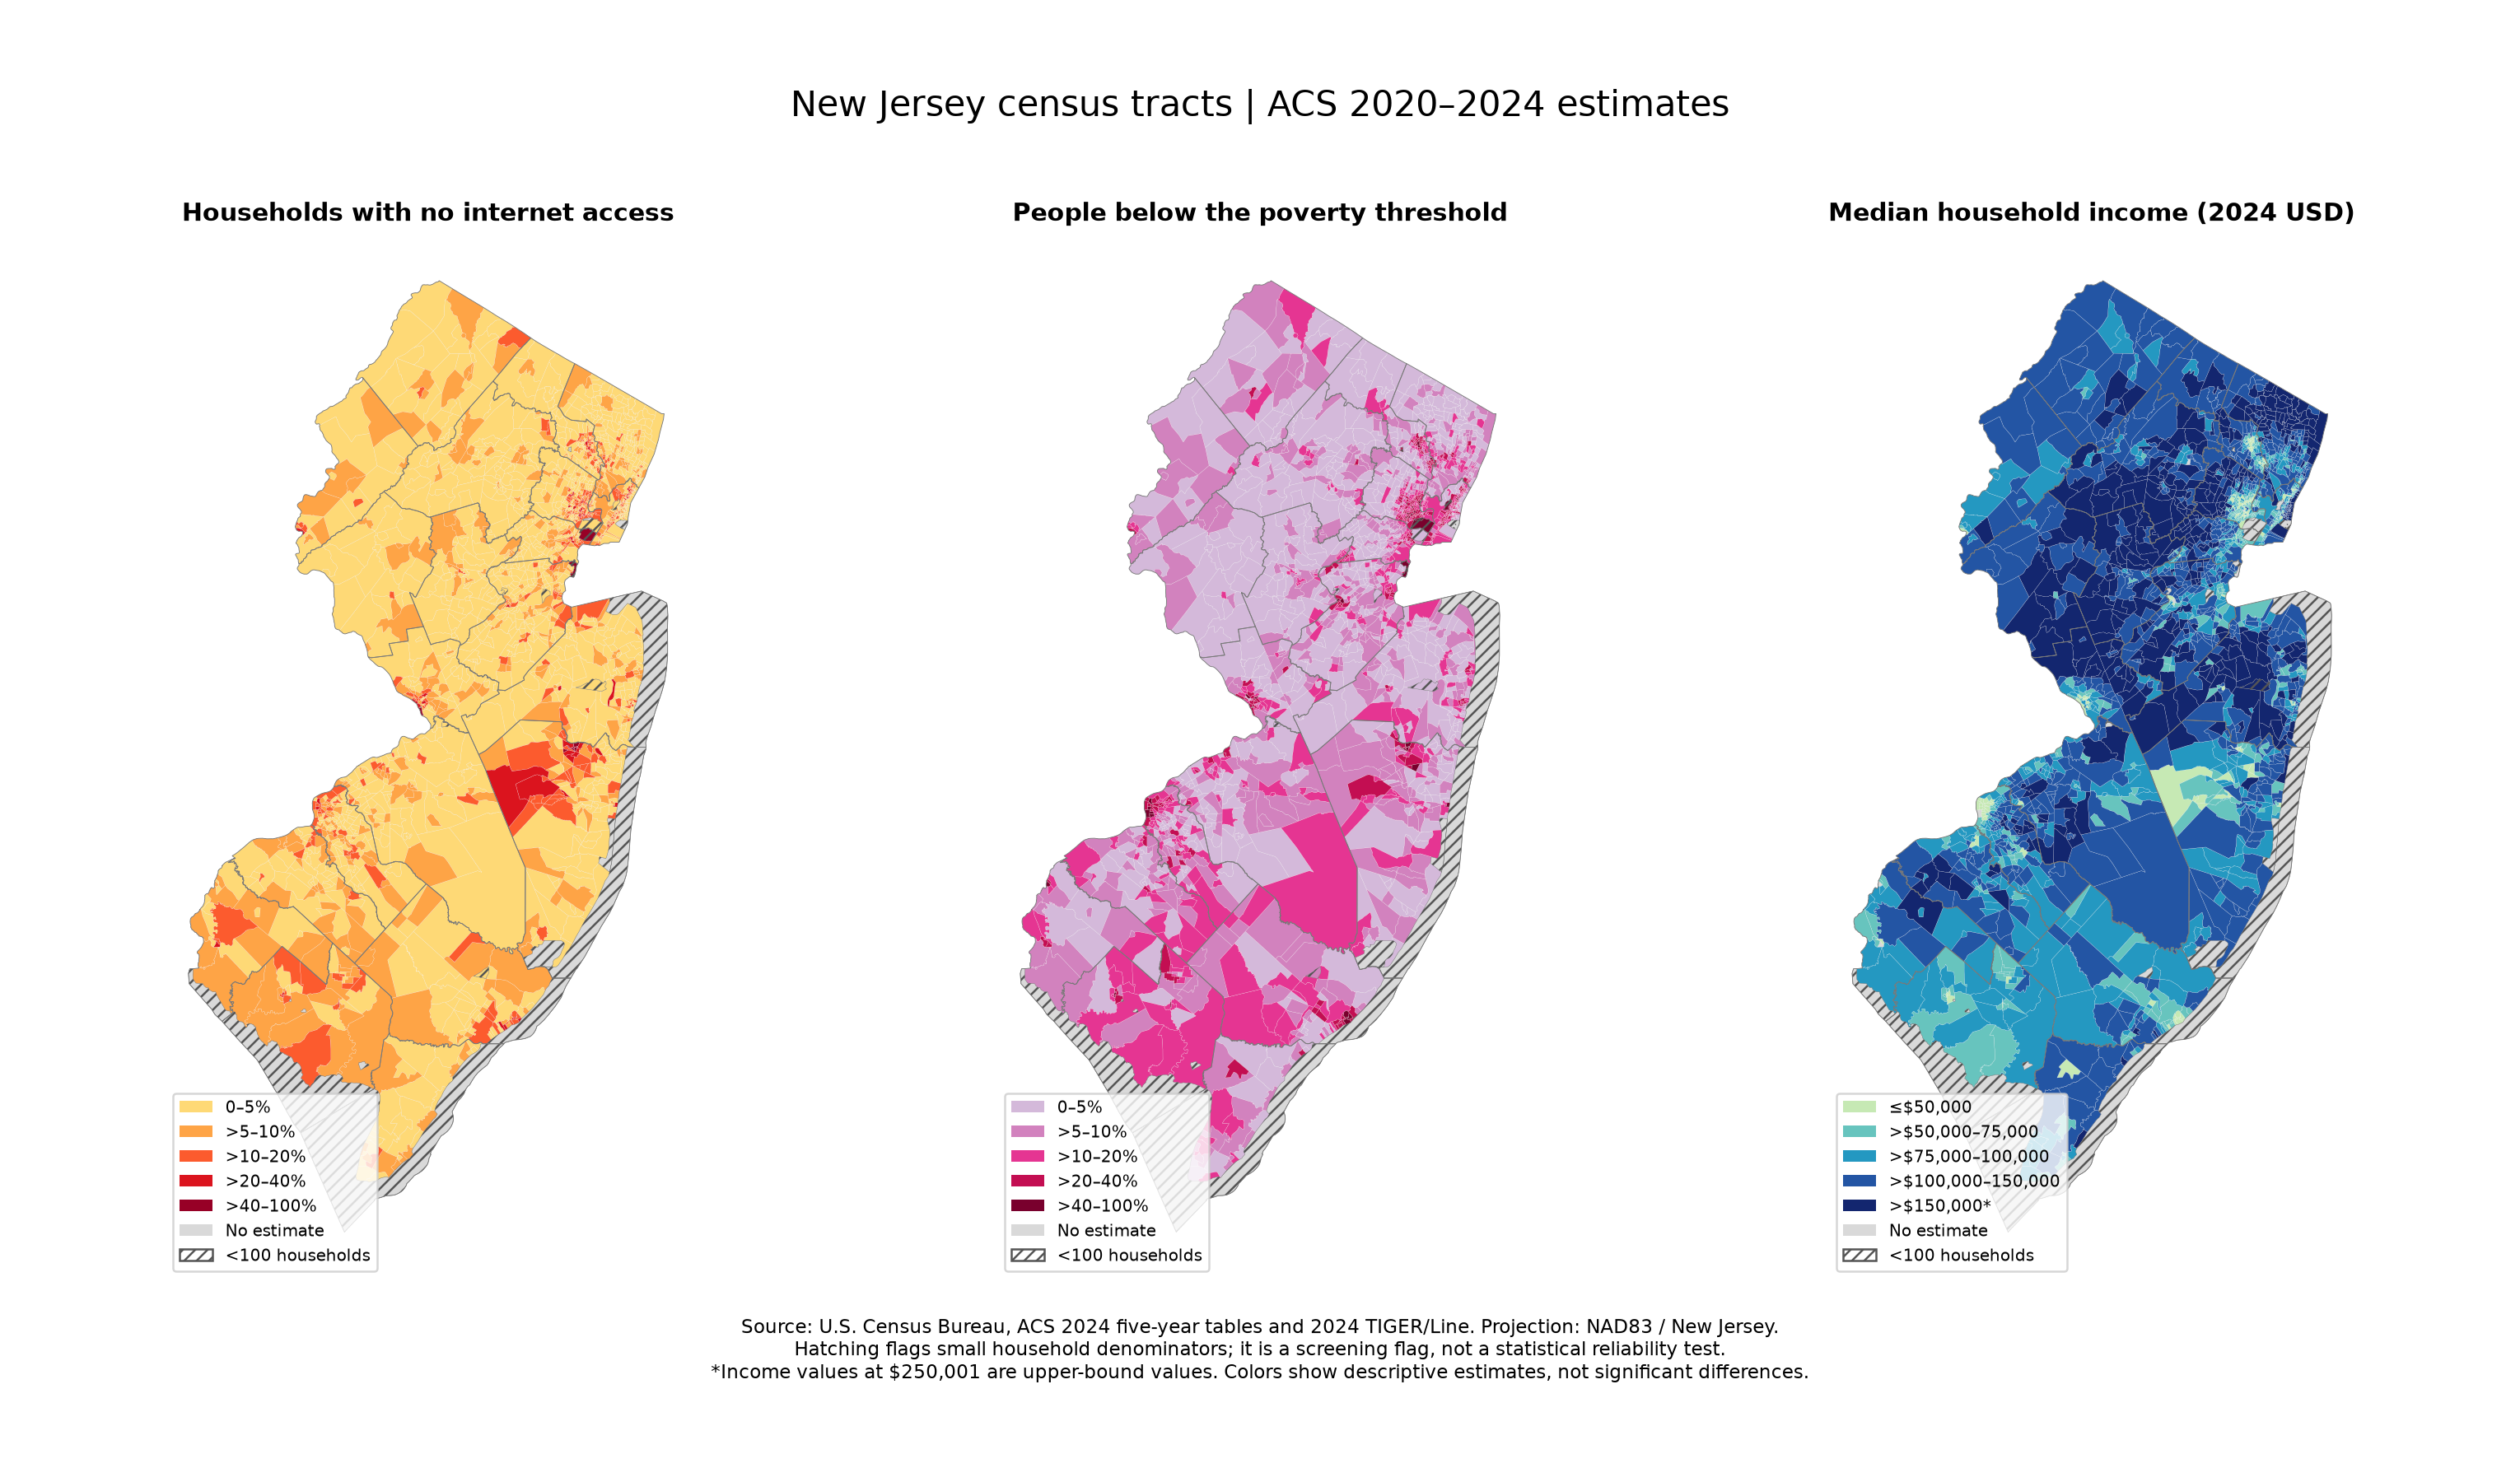

,variable,class,tracts
0,no_internet_access_pct,0–5%,1295
1,no_internet_access_pct,>5–10%,544
2,no_internet_access_pct,>10–20%,268
3,no_internet_access_pct,>20–40%,50
4,no_internet_access_pct,>40–100%,9
5,poverty_pct,0–5%,790
6,poverty_pct,>5–10%,591
7,poverty_pct,>10–20%,493
8,poverty_pct,>20–40%,253
9,poverty_pct,>40–100%,41


Missing map estimates: {'no_internet_access_pct': 15, 'poverty_pct': 13, 'median_household_income_usd': 31}


In [34]:
# 34. Map internet access together with poverty and income.
# Fixed, stated class boundaries make colors interpretable; no values are deleted.
display(Markdown('## 34. Three tract maps: access, poverty and income'))
fig, axes = plt.subplots(1, 3, figsize=(17, 10))
map_specs = [
    ('no_internet_access_pct', 'Households with no internet access',
     [0, 5, 10, 20, 40, 100], ['0–5%', '>5–10%', '>10–20%', '>20–40%', '>40–100%'], 'YlOrRd'),
    ('poverty_pct', 'People below the poverty threshold',
     [0, 5, 10, 20, 40, 100], ['0–5%', '>5–10%', '>10–20%', '>20–40%', '>40–100%'], 'PuRd'),
    ('median_household_income_usd', 'Median household income (2024 USD)',
     [0, 50000, 75000, 100000, 150000, np.inf], ['≤$50,000', '>$50,000–75,000', '>$75,000–100,000', '>$100,000–150,000', '>$150,000*'], 'YlGnBu'),
]
class_counts = []
for ax, (variable, title, bins, labels, cmap_name) in zip(axes, map_specs):
    classes = pd.cut(tract_map[variable], bins=bins, labels=False, include_lowest=True)
    colors = plt.get_cmap(cmap_name)(np.linspace(.25, .95, 5))
    tract_map.plot(ax=ax, color='#d9d9d9', linewidth=0)
    for k, (label, color) in enumerate(zip(labels, colors)):
        selected = tract_map.loc[classes.eq(k)]
        if len(selected): selected.plot(ax=ax, color=color, linewidth=.07, edgecolor='white')
        class_counts.append({'variable': variable, 'class': label, 'tracts': len(selected)})
    small = tract_map.loc[tract_map['households'].lt(100)]
    small.plot(ax=ax, facecolor='none', edgecolor='#555555', linewidth=.15, hatch='////')
    county_outlines.boundary.plot(ax=ax, color='#777777', linewidth=.35)
    handles = [Patch(facecolor=c, label=l) for c, l in zip(colors, labels)]
    handles += [Patch(facecolor='#d9d9d9', label='No estimate'),
                Patch(facecolor='white', edgecolor='#555555', hatch='////', label='<100 households')]
    ax.legend(handles=handles, loc='lower left', fontsize=8, frameon=True)
    ax.set_title(title, fontsize=12)
    ax.set_axis_off()
fig.suptitle('New Jersey census tracts | ACS 2020–2024 estimates', fontsize=17, y=.94)
fig.text(.5, .07, 'Source: U.S. Census Bureau, ACS 2024 five-year tables and 2024 TIGER/Line. Projection: NAD83 / New Jersey.\nHatching flags small household denominators; it is a screening flag, not a statistical reliability test.\n*Income values at $250,001 are upper-bound values. Colors show descriptive estimates, not significant differences.',
         ha='center', fontsize=9)
fig.tight_layout(rect=[0, .12, 1, .92])
fig.savefig(FIGURES / '05_tract_access_poverty_income_maps.png', dpi=180)
plt.close(fig)
from IPython.display import Image
display(Image(filename=str(FIGURES / '05_tract_access_poverty_income_maps.png'), width=1100))
display(pd.DataFrame(class_counts))
print('Missing map estimates:', tract_map[['no_internet_access_pct', 'poverty_pct', 'median_household_income_usd']].isna().sum().to_dict())

## 35. Bivariate map: poverty × lack of internet access

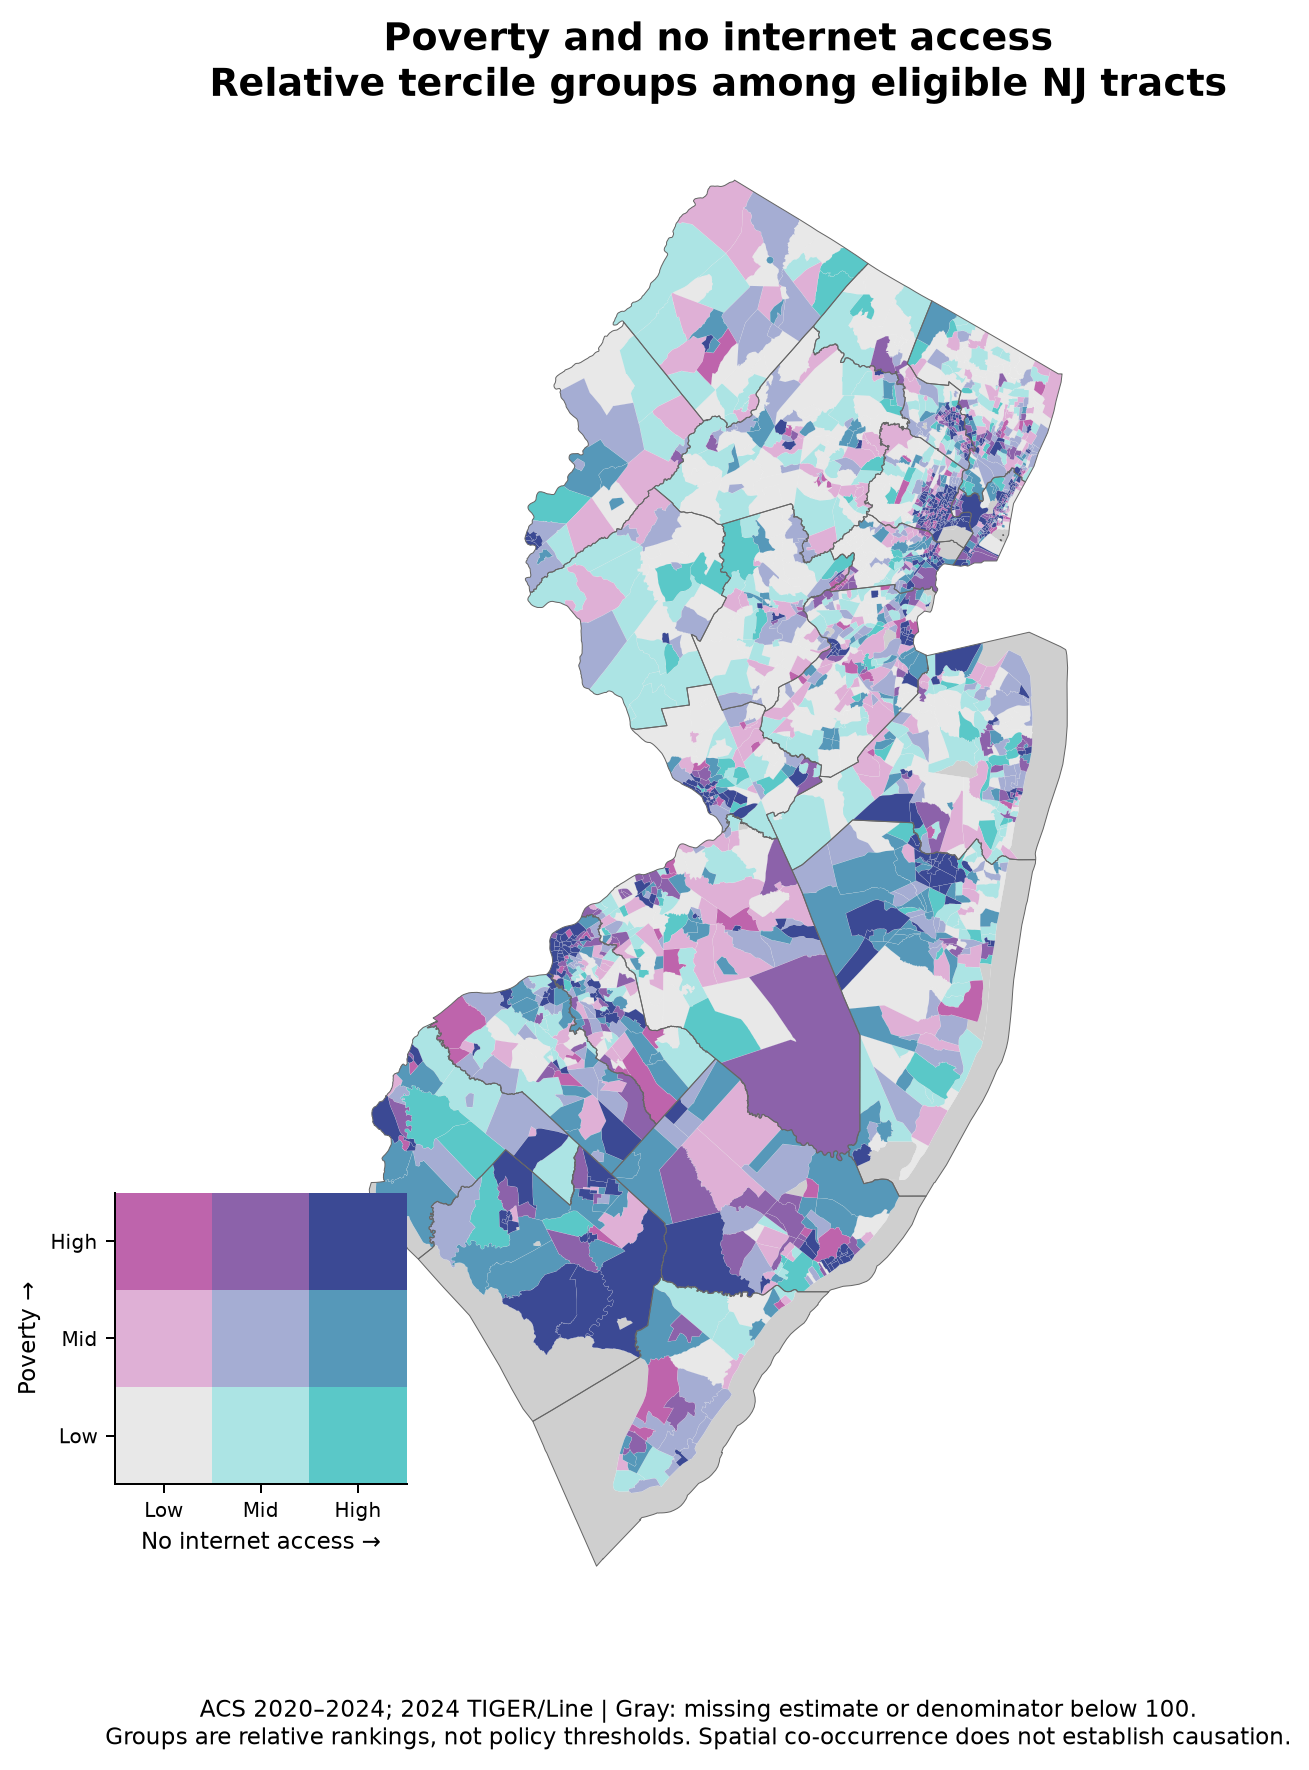

,variable,lower tercile cut (%),upper tercile cut (%)
0,poverty_pct,4.61,10.66
1,no_internet_access_pct,2.44,5.91


no_internet_access_pct_tertile,Low,Mid,High
poverty_pct_tertile,,,
Low,388,248,83
Mid,226,261,232
High,105,210,404


Eligible tracts: 2157 | Gray/excluded tracts: 24
Map pattern describes co-occurrence; it is not a test of spatial clustering or causation.


In [35]:
# 35. Combine poverty and internet-access disadvantage in one exploratory map.
display(Markdown('## 35. Bivariate map: poverty × lack of internet access'))
# Use stated screening thresholds; keep excluded areas gray and report their number.
bivariate_ok = (tract_map['households'].ge(100) & tract_map['poverty_universe_population'].ge(100)
                & tract_map[['poverty_pct', 'no_internet_access_pct']].notna().all(axis=1))
cuts = {}
for var in ['poverty_pct', 'no_internet_access_pct']:
    cuts[var] = tract_map.loc[bivariate_ok, var].quantile([1/3, 2/3]).to_numpy()
    tract_map[var + '_tertile'] = np.nan
    tract_map.loc[bivariate_ok, var + '_tertile'] = np.searchsorted(cuts[var], tract_map.loc[bivariate_ok, var], side='left')
palette = np.array([['#e8e8e8', '#ace4e4', '#5ac8c8'],
                    ['#dfb0d6', '#a5add3', '#5698b9'],
                    ['#be64ac', '#8c62aa', '#3b4994']])
tract_map['bivariate_class'] = np.nan
tract_map.loc[bivariate_ok, 'bivariate_class'] = (3 * tract_map.loc[bivariate_ok, 'poverty_pct_tertile']
                                               + tract_map.loc[bivariate_ok, 'no_internet_access_pct_tertile'])
fig, ax = plt.subplots(figsize=(9, 11))
tract_map.plot(ax=ax, color='#cfcfcf', linewidth=0)
for poverty_level in range(3):
    for access_level in range(3):
        selected = tract_map.loc[tract_map['bivariate_class'].eq(3 * poverty_level + access_level)]
        if len(selected): selected.plot(ax=ax, color=palette[poverty_level, access_level], linewidth=.05, edgecolor='white')
county_outlines.boundary.plot(ax=ax, color='#666666', linewidth=.4)
ax.set_title('Poverty and no internet access\nRelative tercile groups among eligible NJ tracts', fontsize=15)
ax.set_axis_off()
legend_ax = fig.add_axes([.14, .17, .18, .18])
legend_ax.imshow(np.arange(9).reshape(3, 3), origin='lower', cmap=ListedColormap(palette.flatten()), vmin=-.5, vmax=8.5)
legend_ax.set_xticks([0, 1, 2], ['Low', 'Mid', 'High'], fontsize=8)
legend_ax.set_yticks([0, 1, 2], ['Low', 'Mid', 'High'], fontsize=8)
legend_ax.set_xlabel('No internet access →', fontsize=9)
legend_ax.set_ylabel('Poverty →', fontsize=9)
fig.text(.5, .055, 'ACS 2020–2024; 2024 TIGER/Line | Gray: missing estimate or denominator below 100.\nGroups are relative rankings, not policy thresholds. Spatial co-occurrence does not establish causation.', ha='center', fontsize=9)
fig.savefig(FIGURES / '06_bivariate_poverty_no_access_map.png', dpi=180, bbox_inches='tight')
plt.close(fig)
from IPython.display import Image
display(Image(filename=str(FIGURES / '06_bivariate_poverty_no_access_map.png'), width=700))
display(pd.DataFrame([{'variable': var, 'lower tercile cut (%)': cut[0], 'upper tercile cut (%)': cut[1]}
                      for var, cut in cuts.items()]).round(2))
display(pd.crosstab(tract_map.loc[bivariate_ok, 'poverty_pct_tertile'].map({0:'Low',1:'Mid',2:'High'}),
                    tract_map.loc[bivariate_ok, 'no_internet_access_pct_tertile'].map({0:'Low',1:'Mid',2:'High'})).reindex(index=['Low','Mid','High'], columns=['Low','Mid','High']))
print('Eligible tracts:', int(bivariate_ok.sum()), '| Gray/excluded tracts:', int((~bivariate_ok).sum()))
print('Map pattern describes co-occurrence; it is not a test of spatial clustering or causation.')

In [36]:
# 36. Save GIS outputs and refresh the existing results package.
display(Markdown('## 36. Save the tract layer and updated results'))
gis_output = CLEAN / 'nj_tract_digital_equity.gpkg'
tract_map.drop(columns=['geoid']).to_file(gis_output, layer='nj_tract_digital_equity', driver='GPKG')
reopened_gis = gpd.read_file(gis_output, layer='nj_tract_digital_equity')
assert len(reopened_gis) == len(tract) and set(reopened_gis['GEOID']) == set(tract['geoid'])
with zipfile.ZipFile(OUTPUT_ZIP, 'w', zipfile.ZIP_DEFLATED) as archive:
    for folder in [CLEAN, RESULTS]:
        for p in sorted(folder.rglob('*')):
            if p.is_file(): archive.write(p, p.relative_to(ROOT))
with zipfile.ZipFile(OUTPUT_ZIP) as archive:
    assert archive.testzip() is None
display(pd.DataFrame([{'output': p.name, 'bytes': p.stat().st_size}
                      for p in [gis_output, FIGURES / '05_tract_access_poverty_income_maps.png',
                                FIGURES / '06_bivariate_poverty_no_access_map.png', OUTPUT_ZIP]]))
print('PASS: saved GeoPackage reopened with', len(reopened_gis), 'matched tract polygons.')
print('The existing results ZIP now includes the GIS layer, descriptive summary and maps.')
print('Run Step 28 again with SAVE_TO_DRIVE=True if you want to copy this updated ZIP to Drive.')

## 36. Save the tract layer and updated results

,output,bytes
0,nj_tract_digital_equity.gpkg,13504512
1,05_tract_access_poverty_income_maps.png,1216288
2,06_bivariate_poverty_no_access_map.png,477788
3,NJ_Digital_Equity_Results.zip,11691588


PASS: saved GeoPackage reopened with 2181 matched tract polygons.
The existing results ZIP now includes the GIS layer, descriptive summary and maps.
Run Step 28 again with SAVE_TO_DRIVE=True if you want to copy this updated ZIP to Drive.
